<a href="https://colab.research.google.com/github/ianchong208-creator/CP2/blob/main/CP2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install Library**

In [4]:
!pip install xgboost imbalanced-learn shap --quiet

**Import Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neural_network  import MLPClassifier
from xgboost                 import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
)

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# SHAP
import shap

# Styling
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

**Load Dataset**

In [6]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
df.head()

Dataset loaded successfully!
   Rows    : 1470
   Columns : 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Dataset Overview**

In [7]:
print("DATASET OVERVIEW")

print("Column Names & Types:")
print(df.dtypes)

print("Missing Values:")
missing = df.isnull().sum()
print("No missing values" if missing.sum() == 0 else missing[missing > 0])

print("Attrition Distribution:")
counts = df['Attrition'].value_counts()
print(counts)
print(f"Attrition Rate : {counts['Yes'] / len(df) * 100:.2f}%")
print(f"Retention Rate : {counts['No']  / len(df) * 100:.2f}%")

print("Unique Values in Categorical Columns:")
for col in df.select_dtypes(include='object').columns:
    print(f"   {col}: {df[col].unique()}")

print("Constant / Useless Columns:")
for col in ['EmployeeCount', 'StandardHours', 'Over18']:
    print(f"   {col}: {df[col].unique()} → will be dropped")

DATASET OVERVIEW
Column Names & Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel

**Attrition Distribution**

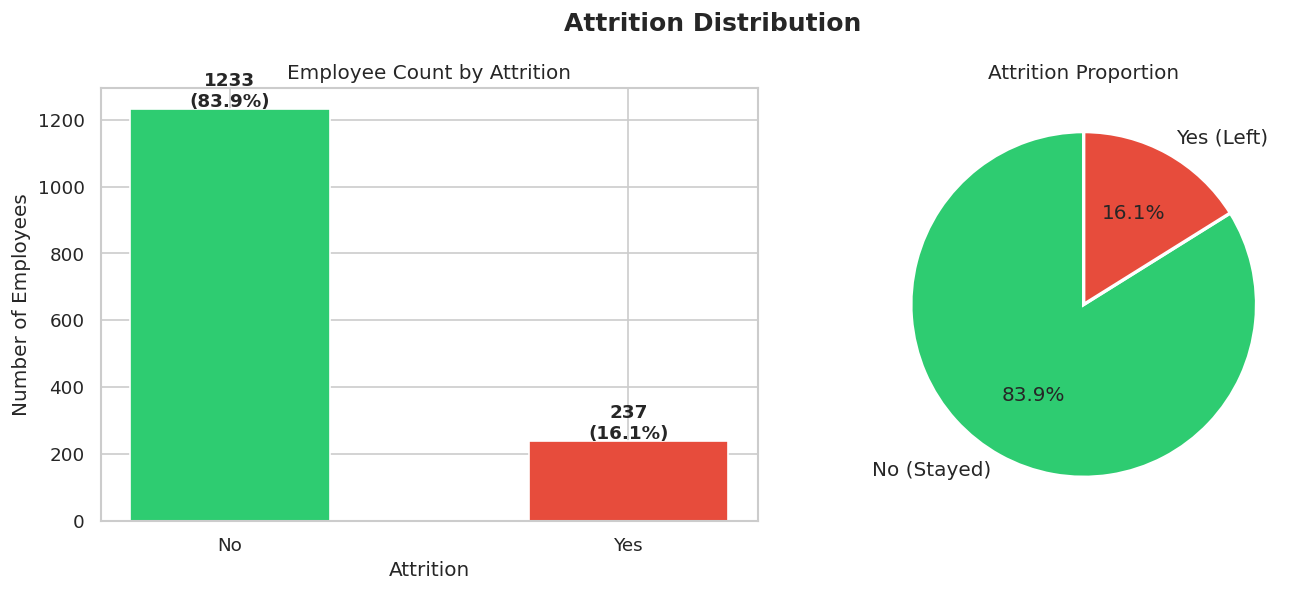

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Attrition Distribution", fontsize=15, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']
counts = df['Attrition'].value_counts()

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors,
                   edgecolor='white', width=0.5)
axes[0].set_title('Employee Count by Attrition')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 8,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=['No (Stayed)', 'Yes (Left)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Attrition Proportion')

plt.tight_layout()
plt.savefig('01_attrition_distribution.png', bbox_inches='tight')
plt.show()

**Numerical Features vs Attrition**

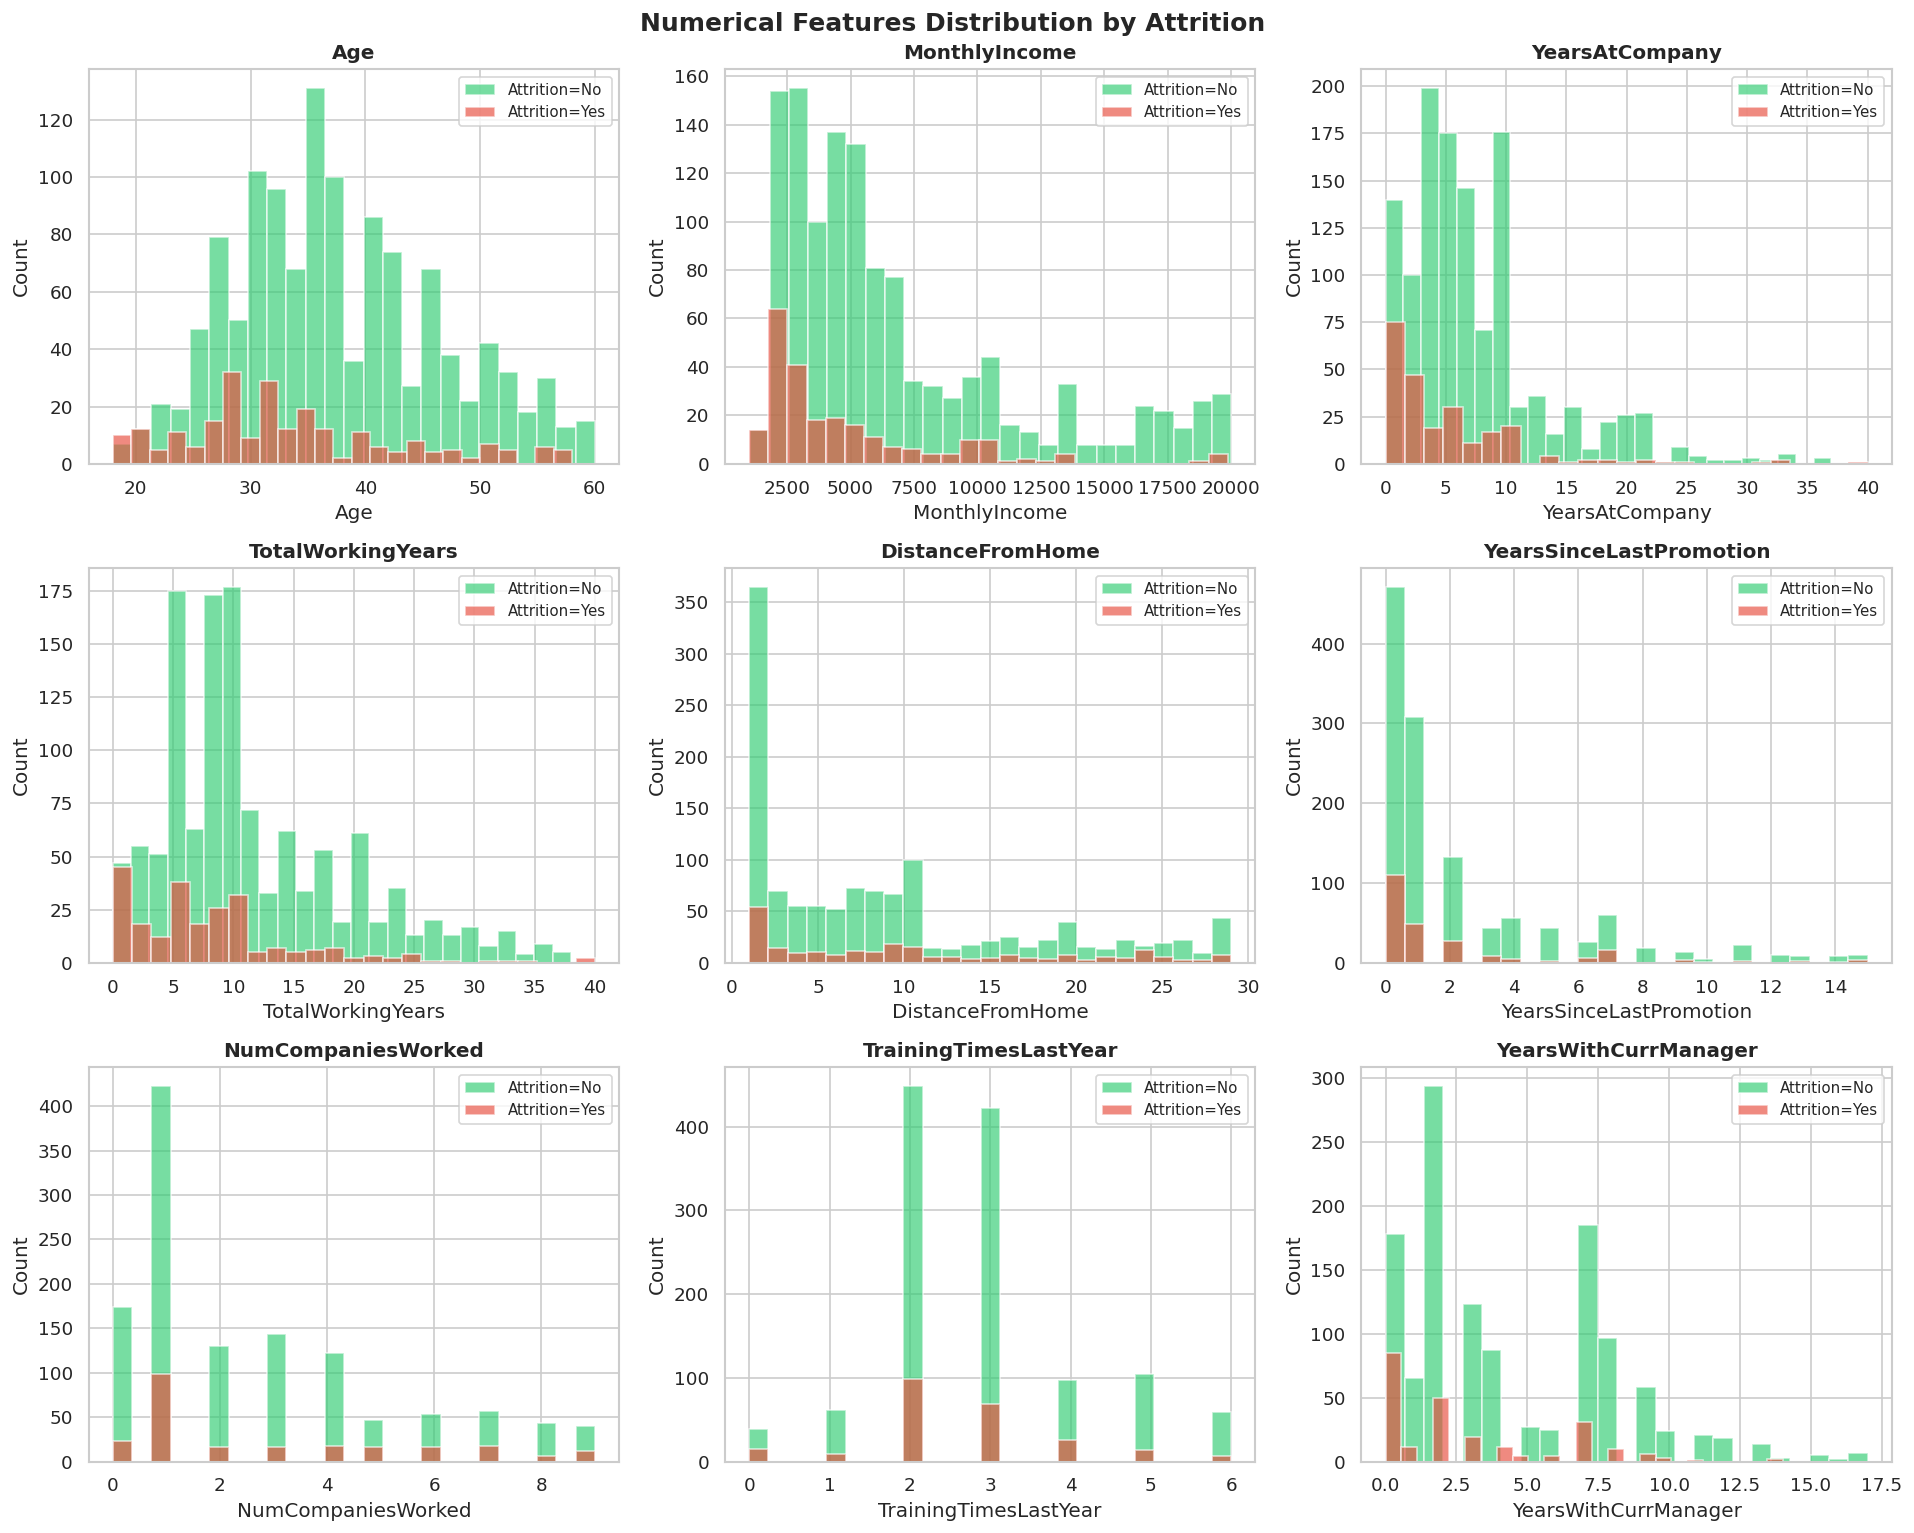

In [9]:
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany',
            'TotalWorkingYears', 'DistanceFromHome',
            'YearsSinceLastPromotion', 'NumCompaniesWorked',
            'TrainingTimesLastYear', 'YearsWithCurrManager']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Numerical Features Distribution by Attrition",
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        axes[i].hist(df[df['Attrition'] == label][col],
                     bins=25, alpha=0.65, color=color,
                     label=f'Attrition={label}', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('02_numerical_features.png', bbox_inches='tight')
plt.show()

**Categorical Features vs Attrition**

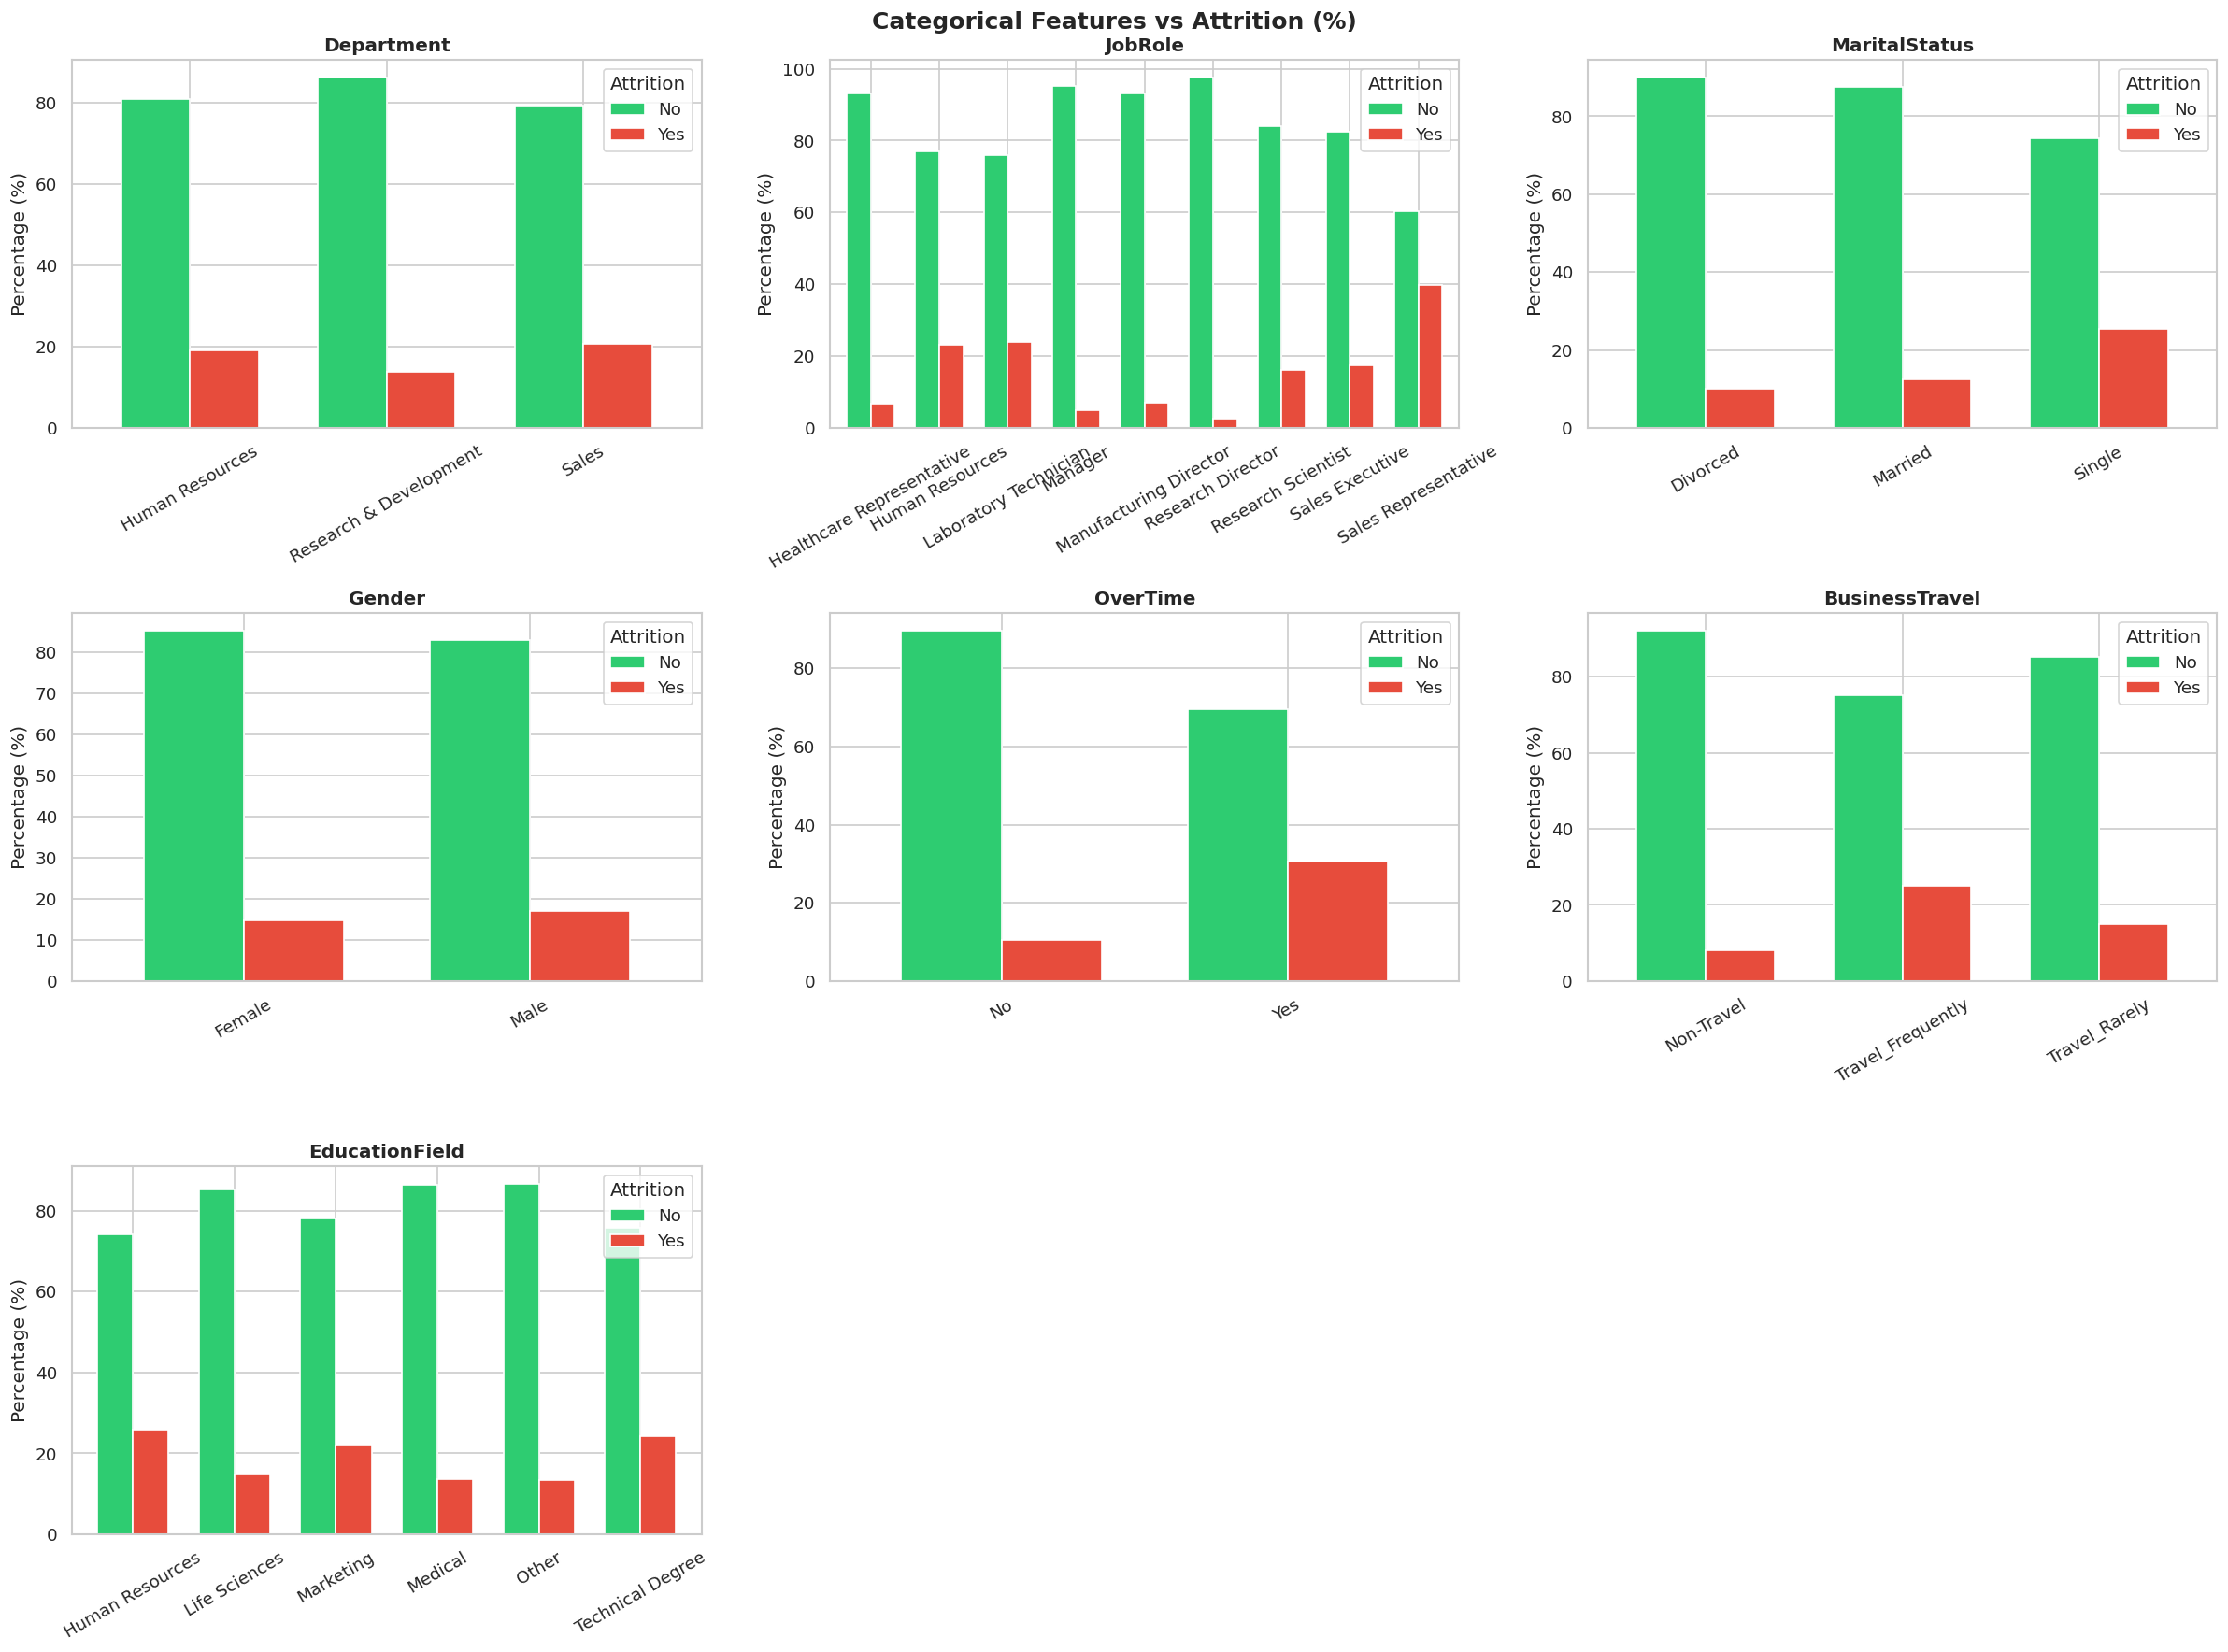

In [10]:
cat_cols = ['Department', 'JobRole', 'MaritalStatus',
            'Gender', 'OverTime', 'BusinessTravel', 'EducationField']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle("Categorical Features vs Attrition (%)",
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    ct[['No','Yes']].plot(kind='bar', ax=axes[i],
                          color=['#2ecc71', '#e74c3c'],
                          edgecolor='white', width=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Attrition', labels=['No', 'Yes'])

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('03_categorical_features.png', bbox_inches='tight')
plt.show()

**Satisfaction & Engagement Scores**

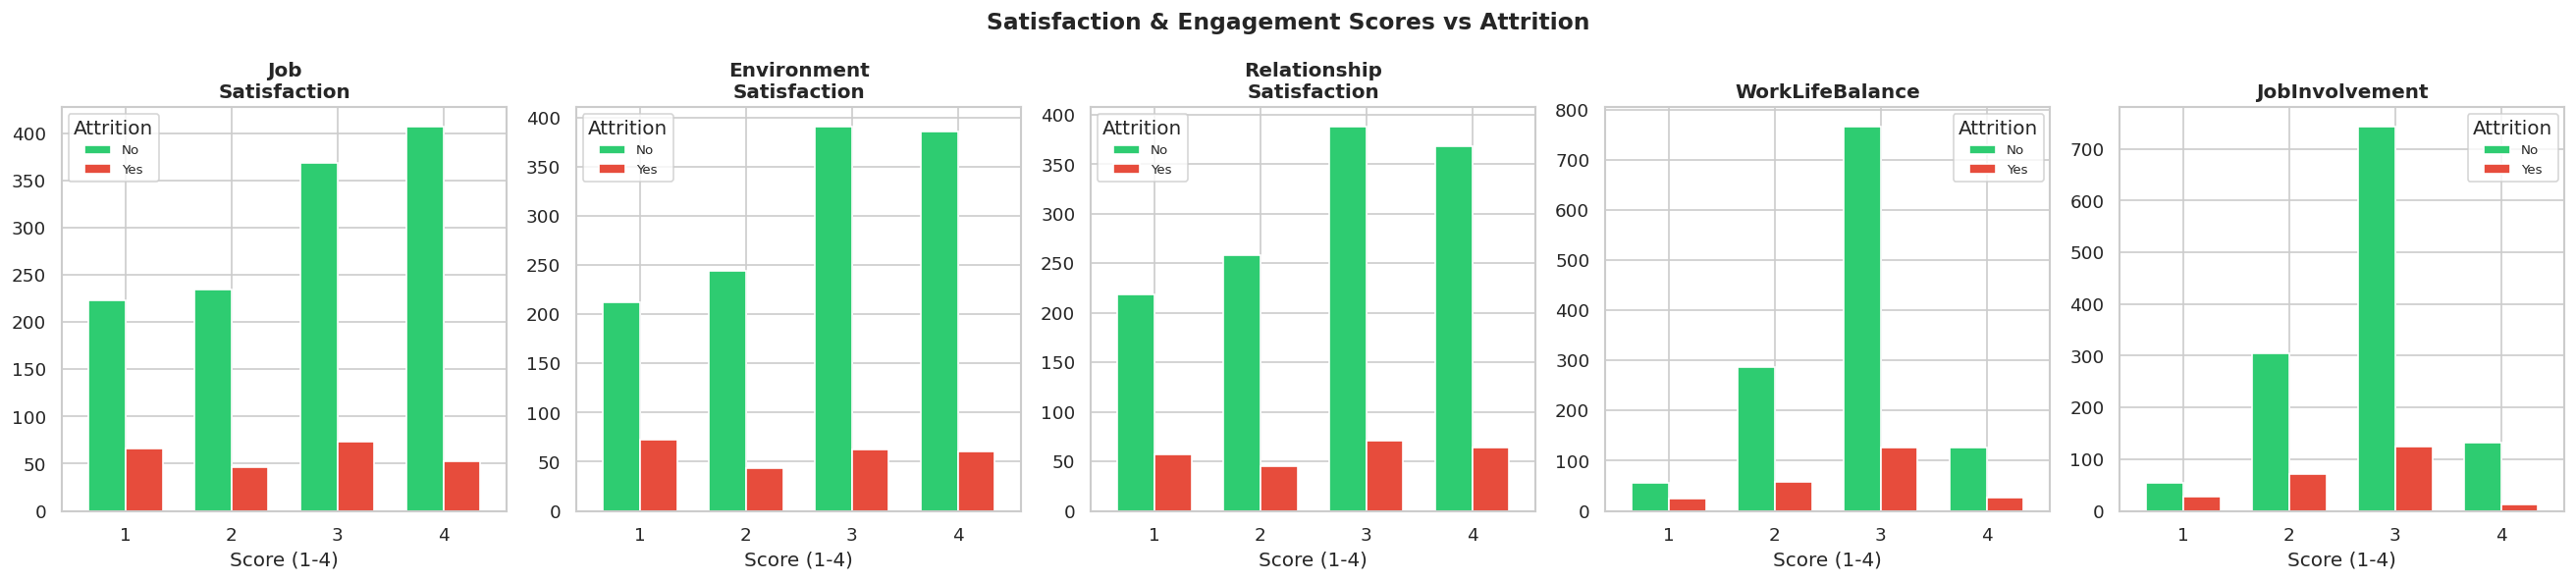

In [11]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Satisfaction & Engagement Scores vs Attrition",
             fontsize=14, fontweight='bold')

for i, col in enumerate(sat_cols):
    ct = pd.crosstab(df[col], df['Attrition'])
    ct[['No','Yes']].plot(kind='bar', ax=axes[i],
                          color=['#2ecc71', '#e74c3c'],
                          edgecolor='white', width=0.7)
    axes[i].set_title(col.replace('Satisfaction','\nSatisfaction'), fontweight='bold')
    axes[i].set_xlabel('Score (1-4)')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Attrition', labels=['No', 'Yes'], fontsize=8)

plt.tight_layout()
plt.savefig('04_satisfaction_scores.png', bbox_inches='tight')
plt.show()

**Compensation & Performance**

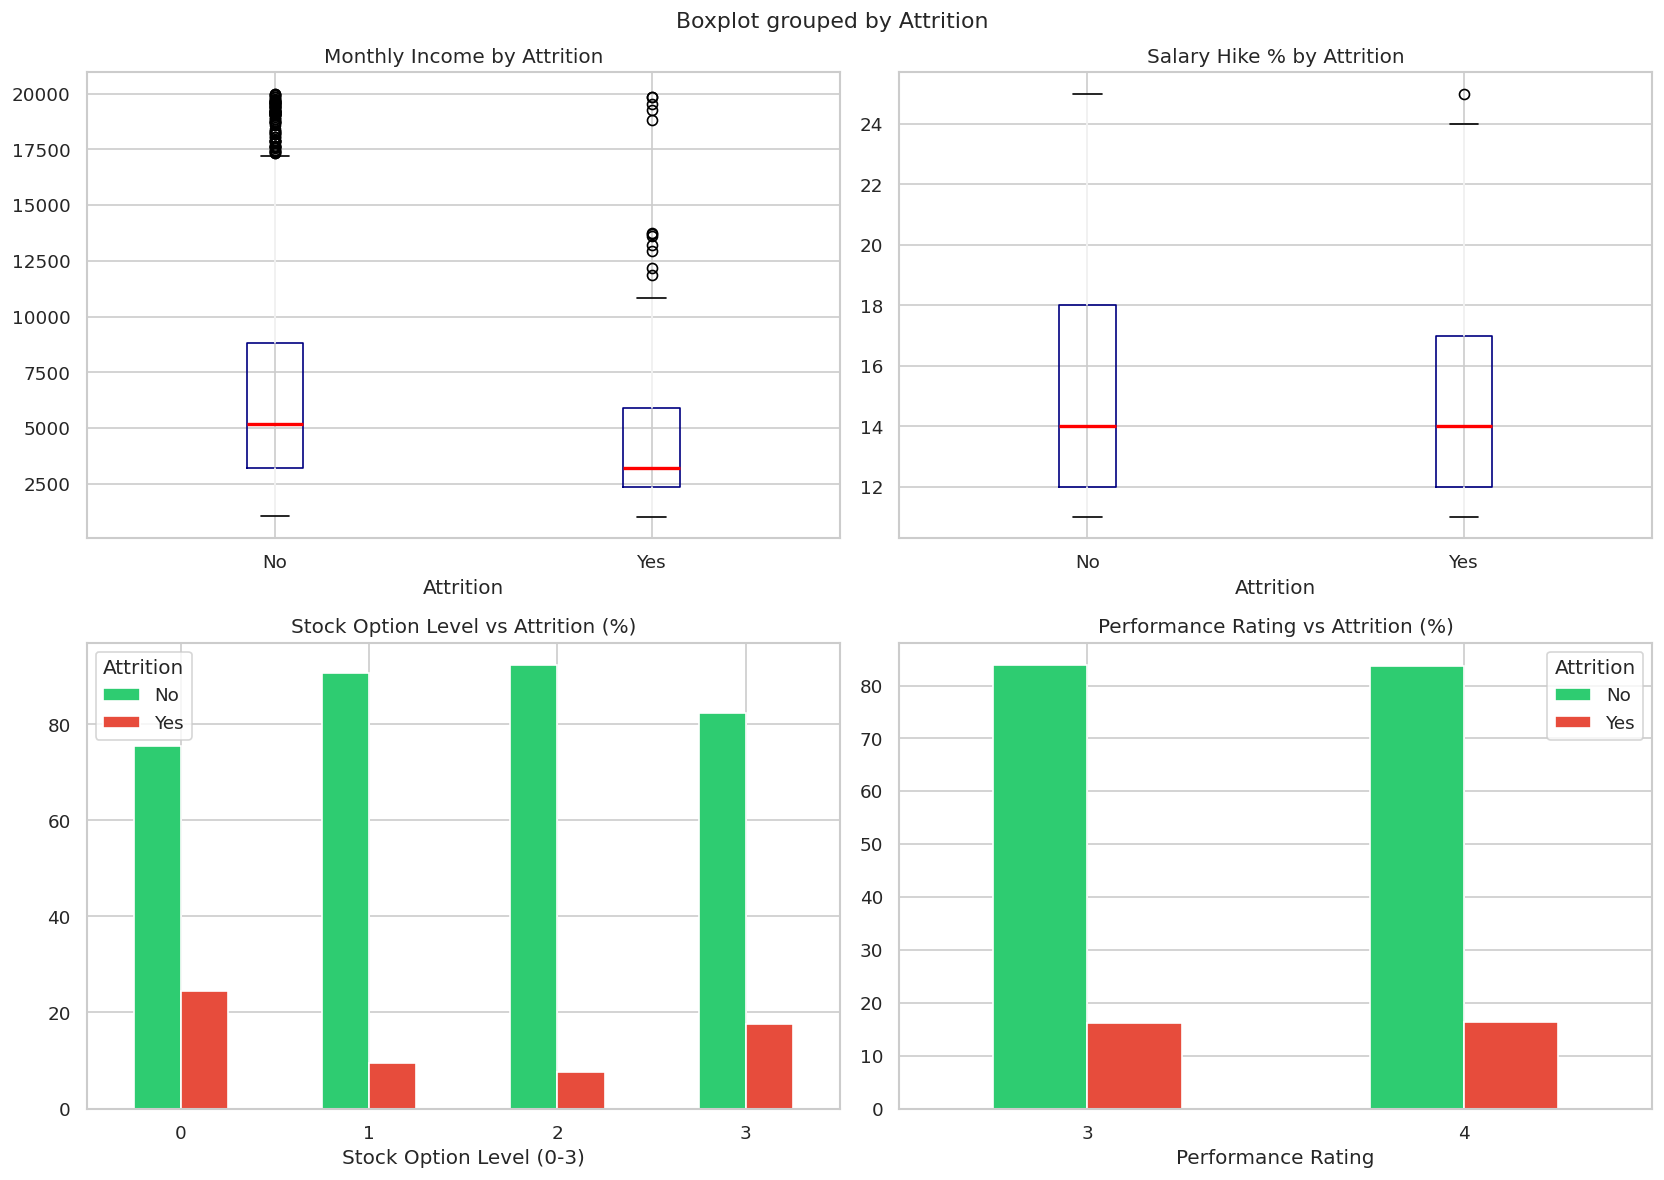

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Compensation & Performance vs Attrition",
             fontsize=14, fontweight='bold')

# Monthly Income boxplot
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[0,0],
           boxprops=dict(color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[0,0].set_title('Monthly Income by Attrition')
axes[0,0].set_xlabel('Attrition'); plt.sca(axes[0,0])
plt.title('Monthly Income by Attrition')

# PercentSalaryHike boxplot
df.boxplot(column='PercentSalaryHike', by='Attrition', ax=axes[0,1],
           boxprops=dict(color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[0,1].set_title('Salary Hike % by Attrition')
axes[0,1].set_xlabel('Attrition')

# StockOptionLevel
ct = pd.crosstab(df['StockOptionLevel'], df['Attrition'], normalize='index') * 100
ct[['No','Yes']].plot(kind='bar', ax=axes[1,0],
                      color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1,0].set_title('Stock Option Level vs Attrition (%)')
axes[1,0].set_xlabel('Stock Option Level (0-3)')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(title='Attrition', labels=['No','Yes'])

# PerformanceRating
ct2 = pd.crosstab(df['PerformanceRating'], df['Attrition'], normalize='index') * 100
ct2[['No','Yes']].plot(kind='bar', ax=axes[1,1],
                       color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1,1].set_title('Performance Rating vs Attrition (%)')
axes[1,1].set_xlabel('Performance Rating')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='Attrition', labels=['No','Yes'])

plt.tight_layout()
plt.savefig('05_compensation_performance.png', bbox_inches='tight')
plt.show()

**Correlation Heatmap**

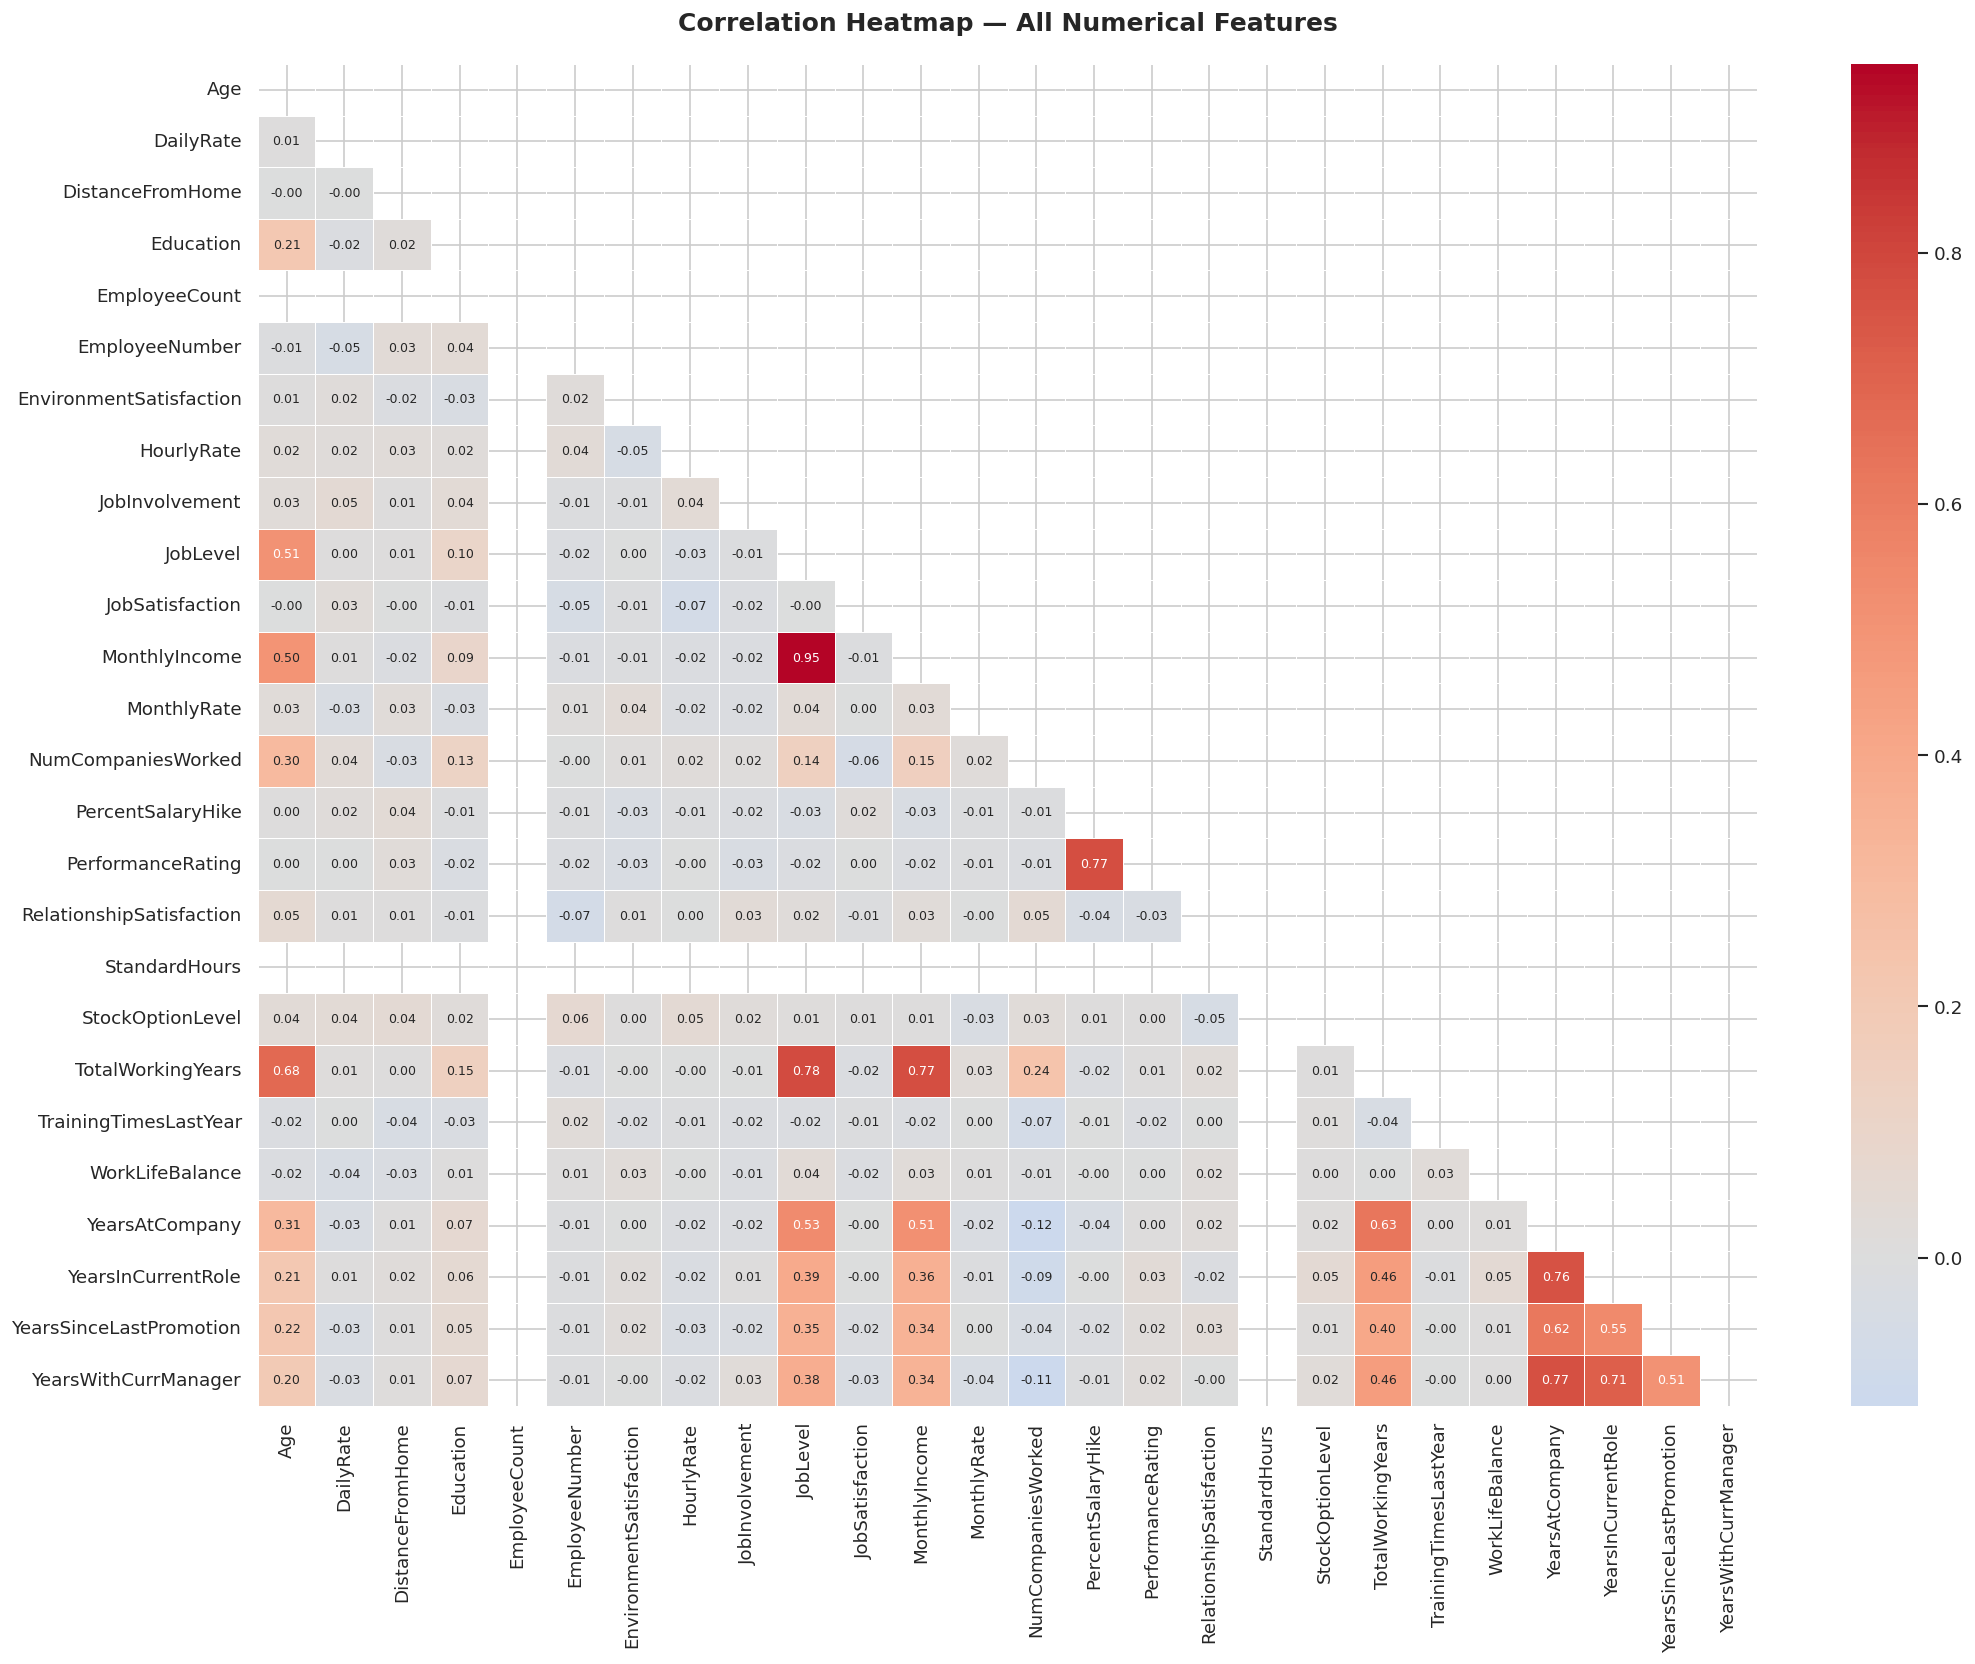

In [13]:
plt.figure(figsize=(18, 14))
num_df = df.select_dtypes(include=np.number)
corr   = num_df.corr()
mask   = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7.5})
plt.title('Correlation Heatmap — All Numerical Features',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Data Preprocessing**

In [14]:
print("DATA PREPROCESSING")
df_clean = df.copy()

# 1. Drop constant & ID columns
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clean.drop(columns=drop_cols, inplace=True)
print(f"\n Dropped columns: {drop_cols}")

# 2. Encode target
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition encoded  → Yes=1, No=0")

# 3. Binary encoding
df_clean['Gender']   = df_clean['Gender'].map({'Male': 1, 'Female': 0})
df_clean['OverTime'] = df_clean['OverTime'].map({'Yes': 1, 'No': 0})
print("Binary encoded     → Gender, OverTime")

# 4. One-hot encoding
ohe_cols = ['Department', 'EducationField', 'JobRole',
            'MaritalStatus', 'BusinessTravel']
df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True)
print(f"One-hot encoded    → {ohe_cols}")
print(f"Shape after preprocessing: {df_clean.shape}")

df_clean.head()

DATA PREPROCESSING

 Dropped columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
Attrition encoded  → Yes=1, No=0
Binary encoded     → Gender, OverTime
One-hot encoded    → ['Department', 'EducationField', 'JobRole', 'MaritalStatus', 'BusinessTravel']
Shape after preprocessing: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,True,False,False,True,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,True,False,False,True,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,False,False,False,False,False,False,True,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,True,False,False,True,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,False,False,False,False,False,True,False,False,True


**Feature Engineering**

In [15]:
print("FEATURE ENGINEERING")

df_eng = df_clean.copy()

df_eng['TenureRatio']       = df_eng['YearsAtCompany'] / (df_eng['TotalWorkingYears'] + 1)
df_eng['PromotionVelocity'] = df_eng['YearsAtCompany'] / (df_eng['YearsSinceLastPromotion'] + 1)
df_eng['IncomePerYear']     = df_eng['MonthlyIncome']  / (df_eng['TotalWorkingYears'] + 1)
df_eng['WorkLifeRisk']      = df_eng['OverTime'] * (5 - df_eng['WorkLifeBalance'])
df_eng['AvgSatisfaction']   = df_eng[['JobSatisfaction',
                                       'EnvironmentSatisfaction',
                                       'RelationshipSatisfaction']].mean(axis=1)

new_feats = ['TenureRatio','PromotionVelocity','IncomePerYear',
             'WorkLifeRisk','AvgSatisfaction']
print("New features created:")
for f in new_feats:
    print(f"   • {f}")

print(f"Final shape: {df_eng.shape}")

FEATURE ENGINEERING
New features created:
   • TenureRatio
   • PromotionVelocity
   • IncomePerYear
   • WorkLifeRisk
   • AvgSatisfaction
Final shape: (1470, 50)


**Train-Test Split & Scaling**

In [16]:
print("TRAIN-TEST SPLIT & SCALING")

X = df_eng.drop('Attrition', axis=1)
y = df_eng['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"80/20 Split:")
print(f"   Train : {X_train.shape[0]} samples  |  {X_train.shape[1]} features")
print(f"   Test  : {X_test.shape[0]} samples")
print(f"\n   Train class — 0: {(y_train==0).sum()}  |  1: {(y_train==1).sum()}")
print(f"   Test  class — 0: {(y_test==0).sum()}   |  1: {(y_test==1).sum()}")

scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),
                           columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),
                           columns=X_test.columns,  index=X_test.index)
print("StandardScaler applied")

TRAIN-TEST SPLIT & SCALING
80/20 Split:
   Train : 1176 samples  |  49 features
   Test  : 294 samples

   Train class — 0: 986  |  1: 190
   Test  class — 0: 247   |  1: 47
StandardScaler applied


In [17]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')
from scipy.stats import loguniform, randint, uniform
from scipy.sparse import hstack, csr_matrix

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (RandomizedSearchCV, RepeatedStratifiedKFold,
                                     StratifiedKFold, cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

SEED  = 42
SCALE = 1.0   # set to 0.25 for a quick test run (fewer random-search configs)
cv_tune = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)
cv_oof  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"'Always predict stay' accuracy on the test set: {1 - y_test.mean():.3f}")
print(f"Leavers in the test set: {int(y_test.sum())}  ->  one more leaver caught moves Recall by {1 / y_test.sum():.3f}")

'Always predict stay' accuracy on the test set: 0.840
Leavers in the test set: 47  ->  one more leaver caught moves Recall by 0.021


**SMOTE**

CLASS IMBALANCE — SMOTE

Before SMOTE → Class 0: 986  |  Class 1: 190
After  SMOTE → Class 0: 986  |  Class 1: 986


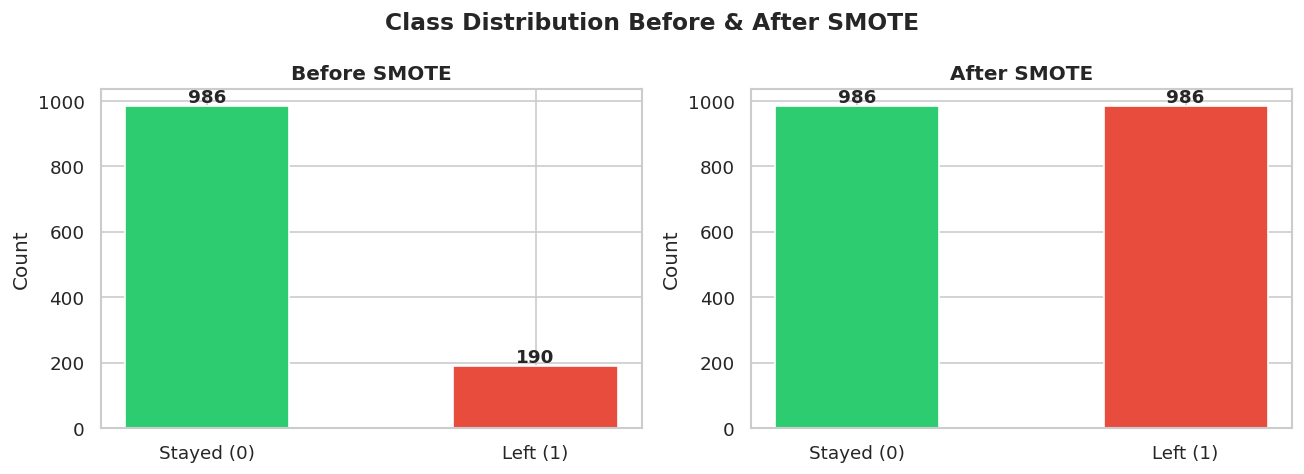

In [18]:
print("CLASS IMBALANCE — SMOTE")

print(f"\nBefore SMOTE → Class 0: {(y_train==0).sum()}  |  Class 1: {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f"After  SMOTE → Class 0: {(y_train_bal==0).sum()}  |  Class 1: {(y_train_bal==1).sum()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Class Distribution Before & After SMOTE",
             fontsize=14, fontweight='bold')

for ax, counts, title in zip(
    axes,
    [pd.Series(y_train).value_counts().sort_index(),
     pd.Series(y_train_bal).value_counts().sort_index()],
    ['Before SMOTE', 'After SMOTE']
):
    bars = ax.bar(['Stayed (0)', 'Left (1)'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 10,
                str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('07_smote.png', bbox_inches='tight')
plt.show()

**Hyperparameter tuning (SMOTE + scaling happen INSIDE each CV fold)**

In [19]:
def make_pipe(clf):
    return ImbPipeline([('scale', StandardScaler()),
                        ('smote', SMOTE(random_state=SEED)),
                        ('clf', clf)])

SMOTE_OPTS = [SMOTE(random_state=SEED), 'passthrough']   # let CV decide whether SMOTE helps

spaces = {
  'Logistic Regression': (LogisticRegression(max_iter=5000, random_state=SEED),
      {'clf__C': loguniform(1e-3, 1e2), 'clf__class_weight': [None, 'balanced'],
       'smote': SMOTE_OPTS}, 25),

  'Decision Tree': (DecisionTreeClassifier(random_state=SEED),
      {'clf__max_depth': randint(2, 9), 'clf__min_samples_leaf': randint(5, 40),
       'clf__min_samples_split': randint(10, 60), 'clf__criterion': ['gini', 'entropy'],
       'clf__class_weight': [None, 'balanced'], 'smote': SMOTE_OPTS}, 40),

  'Random Forest': (RandomForestClassifier(random_state=SEED, n_jobs=1),
      {'clf__n_estimators': randint(200, 500), 'clf__max_depth': [3, 4, 5, 6, 8, 10, None],
       'clf__min_samples_leaf': randint(2, 20), 'clf__max_features': ['sqrt', 'log2', 0.3, 0.5],
       'clf__class_weight': [None, 'balanced', 'balanced_subsample'],
       'smote': SMOTE_OPTS}, 30),

  'XGBoost': (XGBClassifier(eval_metric='logloss', verbosity=0, random_state=SEED, n_jobs=1),
      {'clf__n_estimators': randint(100, 500), 'clf__learning_rate': loguniform(0.01, 0.2),
       'clf__max_depth': randint(2, 6), 'clf__min_child_weight': randint(1, 10),
       'clf__subsample': uniform(0.6, 0.4), 'clf__colsample_bytree': uniform(0.5, 0.5),
       'clf__reg_lambda': loguniform(0.1, 20), 'clf__reg_alpha': loguniform(1e-3, 5),
       'clf__scale_pos_weight': [1, 3, 5], 'smote': SMOTE_OPTS}, 40),

  'SVM': (SVC(kernel='rbf', probability=True, random_state=SEED),
      {'clf__C': loguniform(0.1, 100), 'clf__gamma': loguniform(1e-4, 1e-1),
       'clf__class_weight': [None, 'balanced'], 'smote': SMOTE_OPTS}, 25),

  'Neural Network': (MLPClassifier(early_stopping=True, max_iter=1000, random_state=SEED),
      {'clf__hidden_layer_sizes': [(16,), (32,), (32, 16), (64, 32)],
       'clf__alpha': loguniform(1e-4, 1.0), 'clf__learning_rate_init': loguniform(1e-4, 1e-2),
       'smote': SMOTE_OPTS}, 20),
}

best_pipes = {}
for name, (clf, space, n_iter) in spaces.items():
    n_iter = max(5, int(n_iter * SCALE))
    print(f" {name:<20} {n_iter} configs x 10 folds ...", end=' ', flush=True)
    search = RandomizedSearchCV(make_pipe(clf), space, n_iter=n_iter,
                                scoring='average_precision',      # PR-AUC: honest under imbalance
                                cv=cv_tune, n_jobs=-1, random_state=SEED, refit=True)
    search.fit(X_train, y_train)
    best_pipes[name] = search.best_estimator_
    used = 'no SMOTE' if isinstance(search.best_params_['smote'], str) else 'SMOTE'
    print(f"CV PR-AUC = {search.best_score_:.3f}   ({used})")

🔎 Logistic Regression  25 configs x 10 folds ... CV PR-AUC = 0.662   (no SMOTE)
🔎 Decision Tree        40 configs x 10 folds ... CV PR-AUC = 0.366   (SMOTE)
🔎 Random Forest        30 configs x 10 folds ... CV PR-AUC = 0.581   (SMOTE)
🔎 XGBoost              40 configs x 10 folds ... CV PR-AUC = 0.627   (no SMOTE)
🔎 SVM                  25 configs x 10 folds ... CV PR-AUC = 0.662   (no SMOTE)
🔎 Neural Network       20 configs x 10 folds ... CV PR-AUC = 0.598   (no SMOTE)


**Leak-free hybrids**

In [20]:
class RFNNHybrid(ClassifierMixin, BaseEstimator):
    """Random Forest picks top-k features + gives an out-of-fold probability; a small NN uses both."""
    def __init__(self, k=20, seed=SEED):
        self.k, self.seed = k, seed

    def _rf(self):
        return RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                      class_weight='balanced_subsample',
                                      random_state=self.seed, n_jobs=1)

    def fit(self, X, y):
        X, y = pd.DataFrame(X).reset_index(drop=True), np.asarray(y)
        self.classes_ = np.array([0, 1])
        imp = pd.Series(self._rf().fit(X, y).feature_importances_, index=X.columns)
        self.top_ = list(imp.nlargest(self.k).index)
        Xt = X[self.top_]
        oof = cross_val_predict(self._rf(), Xt, y, cv=5, method='predict_proba')[:, 1]  # no leakage
        self.rf_ = self._rf().fit(Xt, y)
        self.nn_ = ImbPipeline([('sc', StandardScaler()), ('smote', SMOTE(random_state=self.seed)),
                                ('mlp', MLPClassifier(hidden_layer_sizes=(32, 16), alpha=1e-2,
                                                      early_stopping=True, max_iter=1000,
                                                      random_state=self.seed))])
        self.nn_.fit(np.column_stack([Xt.values, oof]), y)
        return self

    def predict_proba(self, X):
        Xt = pd.DataFrame(X)[self.top_]
        rf_p = self.rf_.predict_proba(Xt)[:, 1]
        return self.nn_.predict_proba(np.column_stack([Xt.values, rf_p]))

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


class GBLeafHybrid(ClassifierMixin, BaseEstimator):
    """Shallow XGBoost -> one-hot leaf IDs (+ scaled raw features) -> small head ('mlp' or 'lr')."""
    def __init__(self, head='mlp', n_trees=150, depth=3, seed=SEED):
        self.head, self.n_trees, self.depth, self.seed = head, n_trees, depth, seed

    def _feat(self, X):
        return hstack([self.enc_.transform(self.gb_.apply(X)),
                       csr_matrix(self.sc_.transform(X))]).tocsr()

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y)
        self.classes_ = np.array([0, 1])
        self.gb_ = XGBClassifier(n_estimators=self.n_trees, max_depth=self.depth, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
                                 verbosity=0, random_state=self.seed, n_jobs=1).fit(X, y)
        self.enc_ = OneHotEncoder(handle_unknown='ignore').fit(self.gb_.apply(X))
        self.sc_  = StandardScaler().fit(X)
        if self.head == 'lr':
            self.clf_ = LogisticRegression(C=0.05, class_weight='balanced', max_iter=5000)
        else:
            self.clf_ = MLPClassifier(hidden_layer_sizes=(16,), alpha=1.0, early_stopping=True,
                                      max_iter=1000, random_state=self.seed)
        self.clf_.fit(self._feat(X), y)
        return self

    def predict_proba(self, X):
        return self.clf_.predict_proba(self._feat(np.asarray(X, dtype=float)))

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

hybrids = {
    'RF + NN (leak-free)': RFNNHybrid(),
    'GB + NN (leak-free)': GBLeafHybrid(head='mlp'),
    'GB + LR (leaves)':    GBLeafHybrid(head='lr'),
}

**Ensembles, threshold tuning, final test-set evaluation**

In [21]:
top3 = ['Logistic Regression', 'Random Forest', 'XGBoost']
ensembles = {
    'Voting (LR+RF+XGB)': VotingClassifier(
        [(n.replace(' ', '_'), best_pipes[n]) for n in top3], voting='soft'),
    'Stacking (LR+RF+XGB)': StackingClassifier(
        [(n.replace(' ', '_'), best_pipes[n]) for n in top3],
        final_estimator=LogisticRegression(class_weight='balanced', max_iter=2000),
        stack_method='predict_proba', cv=5),
}

def tune_threshold(est):
    """Pick the F1-maximising threshold from OUT-OF-FOLD predictions on the training set only."""
    oof = cross_val_predict(est, X_train, y_train, cv=cv_oof,
                            method='predict_proba', n_jobs=-1)[:, 1]
    grid = np.linspace(0.05, 0.95, 91)
    f1s = np.array([f1_score(y_train, oof >= t, zero_division=0) for t in grid])
    smooth = np.convolve(f1s, np.ones(5) / 5, mode='same')     # avoid picking a lucky spike
    return grid[int(np.argmax(smooth))]

def f1_ci(y_true, prob, thr, n=2000):
    """Bootstrap 95% CI for F1 — shows how noisy a 47-leaver test set really is."""
    rng, y, p = np.random.default_rng(SEED), np.asarray(y_true), np.asarray(prob)
    vals = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if y[i].sum() > 0:
            vals.append(f1_score(y[i], p[i] >= thr, zero_division=0))
    return np.percentile(vals, [2.5, 97.5])

final_models = {**best_pipes, **ensembles, **hybrids}
rows, preds_v2, probs_v2 = [], {}, {}

for name, est in final_models.items():
    thr = tune_threshold(est)
    if name not in best_pipes:            # ensembles / hybrids are not fitted yet
        est.fit(X_train, y_train)
    prob = est.predict_proba(X_test)[:, 1]
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rec, spec = recall_score(y_test, pred), tn / (tn + fp)
    lo, hi = f1_ci(y_test, prob, thr)
    rows.append({'Model': name, 'Threshold': round(thr, 2),
                 'Accuracy': accuracy_score(y_test, pred),
                 'Precision': precision_score(y_test, pred, zero_division=0),
                 'Recall': rec, 'F1-Score': f1_score(y_test, pred),
                 'ROC-AUC': roc_auc_score(y_test, prob),
                 'PR-AUC': average_precision_score(y_test, prob),
                 'Specificity': spec, 'G-Mean': np.sqrt(rec * spec),
                 'F1 95% CI': f"{lo:.2f}-{hi:.2f}",
                 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn})
    preds_v2[name], probs_v2[name] = pred, prob
    print(f" {name:<24} threshold={thr:.2f}   F1={rows[-1]['F1-Score']:.3f}")

results_v2 = (pd.DataFrame(rows).sort_values('F1-Score', ascending=False)
              .reset_index(drop=True))
if 'results' in globals():               # your old table from Cell 16
    results_v2['F1 before'] = results_v2['Model'].map(results.set_index('Model')['F1-Score'])

show = ['Model', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score',
        'F1 95% CI', 'ROC-AUC', 'PR-AUC', 'Specificity', 'G-Mean'] + \
       (['F1 before'] if 'F1 before' in results_v2 else [])
results_v2.to_csv('model_results_v2.csv', index=False)
results_v2[show].round(3)

✅ Logistic Regression      threshold=0.36   F1=0.530
✅ Decision Tree            threshold=0.44   F1=0.403
✅ Random Forest            threshold=0.41   F1=0.478
✅ XGBoost                  threshold=0.30   F1=0.516
✅ SVM                      threshold=0.34   F1=0.532
✅ Neural Network           threshold=0.28   F1=0.500
✅ Voting (LR+RF+XGB)       threshold=0.30   F1=0.509
✅ Stacking (LR+RF+XGB)     threshold=0.61   F1=0.531
✅ RF + NN (leak-free)      threshold=0.62   F1=0.466
✅ GB + NN (leak-free)      threshold=0.24   F1=0.379
✅ GB + LR (leaves)         threshold=0.48   F1=0.413


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,F1 95% CI,ROC-AUC,PR-AUC,Specificity,G-Mean
0,SVM,0.34,0.850,0.532,0.532,0.532,0.40-0.65,0.799,0.561,0.911,0.696
1,Stacking (LR+RF+XGB),0.61,0.844,0.510,0.553,0.531,0.40-0.64,0.816,0.596,0.899,0.705
2,Logistic Regression,0.36,0.867,0.611,0.468,0.530,0.38-0.65,0.807,0.584,0.943,0.664
3,XGBoost,0.30,0.847,0.522,0.511,0.516,0.38-0.64,0.799,0.531,0.911,0.682
4,Voting (LR+RF+XGB),0.30,0.823,0.458,0.574,0.509,0.38-0.62,0.819,0.594,0.870,0.707
5,Neural Network,0.28,0.823,0.456,0.553,0.500,0.38-0.62,0.788,0.538,0.874,0.696
6,Random Forest,0.41,0.799,0.409,0.574,0.478,0.35-0.59,0.805,0.480,0.842,0.696
7,RF + NN (leak-free),0.62,0.813,0.429,0.511,0.466,0.34-0.58,0.724,0.425,0.870,0.667
8,GB + LR (leaves),0.48,0.816,0.422,0.404,0.413,0.28-0.54,0.794,0.512,0.895,0.601
9,Decision Tree,0.44,0.707,0.299,0.617,0.403,0.30-0.50,0.752,0.387,0.725,0.669


**Re-make the charts with the new results**

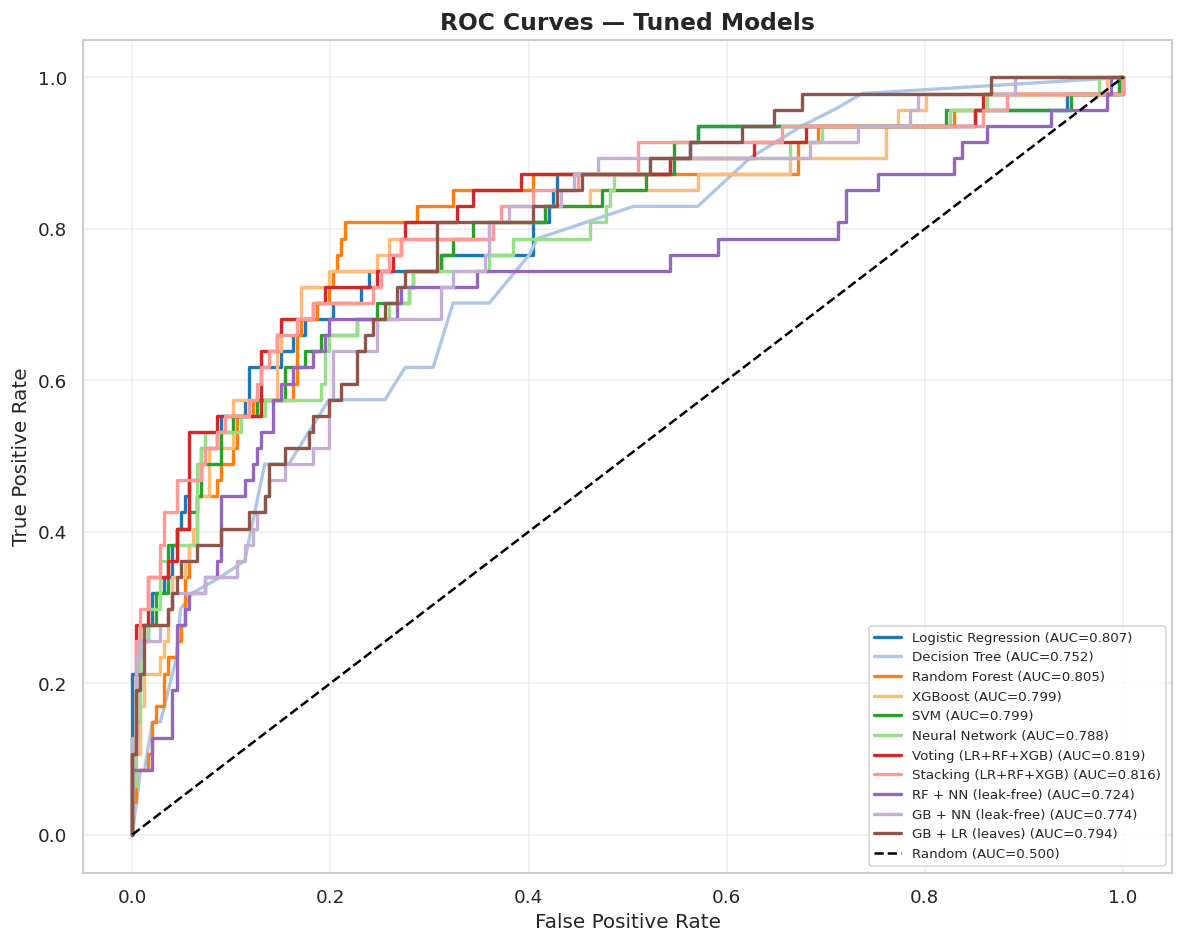

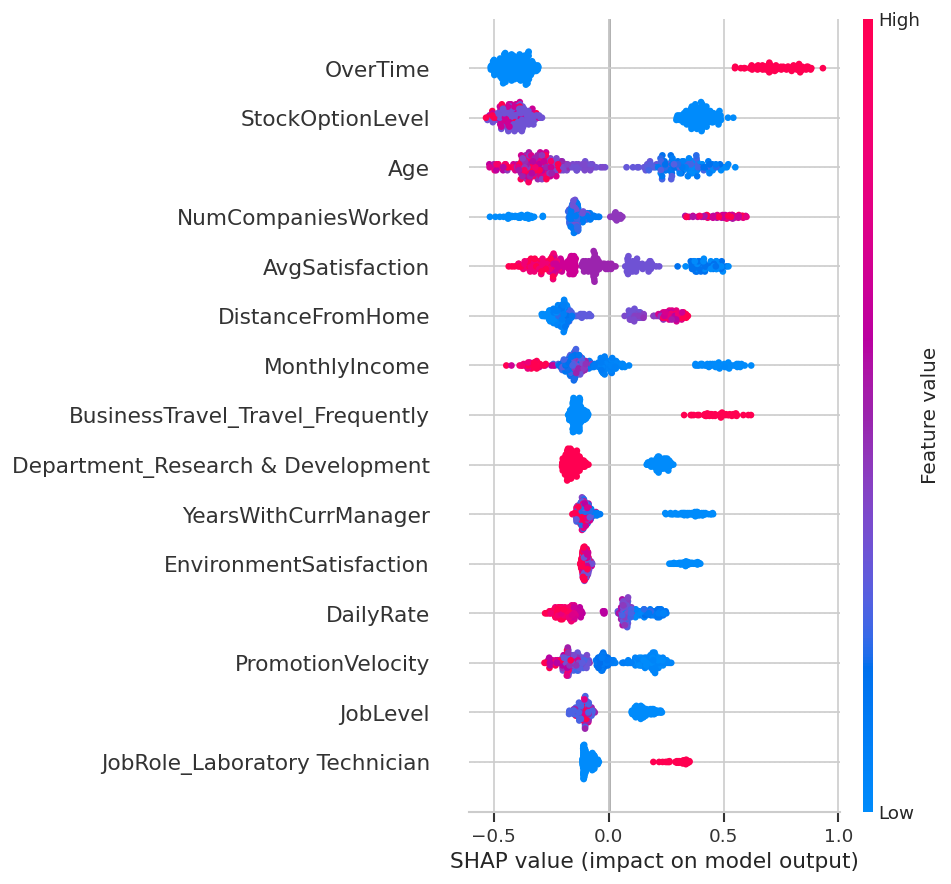

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))
cmap = plt.cm.tab20
for i, (name, prob) in enumerate(probs_v2.items()):
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, color=cmap(i), lw=2, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('17_roc_curves_v2.png', bbox_inches='tight'); plt.show()

# SHAP for the tuned XGBoost (trees don't need scaling, but we reuse the pipeline's scaler)
import shap
xgb_best = best_pipes['XGBoost']
Xte_sc = pd.DataFrame(xgb_best.named_steps['scale'].transform(X_test), columns=X_test.columns)
shap_values = shap.TreeExplainer(xgb_best.named_steps['clf']).shap_values(Xte_sc)
shap.summary_plot(shap_values, Xte_sc, plot_type='dot', max_display=15)

**Train All 6 Models**

In [23]:
print("TRAINING 6 ML MODELS")

spw = (y_train_bal == 0).sum() / (y_train_bal == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000, class_weight='balanced'),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42, max_depth=10,
        min_samples_split=20, min_samples_leaf=10,
        class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, max_depth=15,
        min_samples_split=10, class_weight='balanced', n_jobs=-1),

    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        scale_pos_weight=spw, random_state=42,
        eval_metric='logloss', verbosity=0),

    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        probability=True, class_weight='balanced', random_state=42),

    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32, 16), activation='relu',
        solver='adam', max_iter=500, random_state=42,
        early_stopping=True, validation_fraction=0.1),
}

trained, preds, probs = {}, {}, {}

for name, model in models.items():
    print(f"  {name:<22} ", end='')
    model.fit(X_train_bal, y_train_bal)
    trained[name] = model
    preds[name]   = model.predict(X_test_sc)
    probs[name]   = model.predict_proba(X_test_sc)[:, 1]

print("All 6 models trained!")

TRAINING 6 ML MODELS
  Logistic Regression      Decision Tree            Random Forest            XGBoost                  SVM                      Neural Network         All 6 models trained!


**Random Forest + Neural Network**

In [24]:
print("HYBRID MODEL 1: Random Forest + Neural Network")

# Step 1: Train Random Forest and extract feature importances
print("Step 1: Training Random Forest for feature selection...")
rf_hybrid = RandomForestClassifier(
    n_estimators=200, random_state=42,
    max_depth=15, class_weight='balanced', n_jobs=-1)
rf_hybrid.fit(X_train_bal, y_train_bal)

# Step 2: Select top 20 features based on RF importance
importances  = pd.Series(rf_hybrid.feature_importances_,
                          index=X_train_bal.columns if hasattr(X_train_bal, 'columns')
                          else [f'f{i}' for i in range(X_train_bal.shape[1])])
top20_feats  = importances.nlargest(20).index.tolist()
print(f"Top 20 features selected by Random Forest:")
for i, f in enumerate(top20_feats, 1):
    print(f"   {i:2d}. {f}")

# Step 3: Filter train/test to top 20 features only
X_train_top = X_train_bal[top20_feats] if hasattr(X_train_bal, 'columns') \
              else X_train_bal[:, [list(X_train_bal.columns).index(f) for f in top20_feats]]
X_test_top  = X_test_sc[top20_feats]

# Step 4: Also get RF predicted probabilities as an extra feature
rf_train_prob = rf_hybrid.predict_proba(X_train_bal)[:, 1].reshape(-1, 1)
rf_test_prob  = rf_hybrid.predict_proba(X_test_sc)[:, 1].reshape(-1, 1)

# Step 5: Stack RF prob with top features → feed into Neural Network
X_train_hybrid1 = np.hstack([X_train_top, rf_train_prob])
X_test_hybrid1  = np.hstack([X_test_top,  rf_test_prob])

print(f"Step 2: Training Neural Network on RF-selected features + RF probabilities...")
nn_on_rf = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16), activation='relu',
    solver='adam', max_iter=600, random_state=42,
    early_stopping=True, validation_fraction=0.1,
    learning_rate_init=0.001)
nn_on_rf.fit(X_train_hybrid1, y_train_bal)

# Evaluate
hybrid1_pred = nn_on_rf.predict(X_test_hybrid1)
hybrid1_prob = nn_on_rf.predict_proba(X_test_hybrid1)[:, 1]

trained['RF + Neural Network'] = nn_on_rf
preds['RF + Neural Network']   = hybrid1_pred
probs['RF + Neural Network']   = hybrid1_prob

tn, fp, fn, tp = confusion_matrix(y_test, hybrid1_pred).ravel()
spec_h1  = tn / (tn + fp)
rec_h1   = recall_score(y_test, hybrid1_pred)
print("Hybrid 1 Results:")
print(f"   Accuracy  : {accuracy_score(y_test, hybrid1_pred):.4f}")
print(f"   Precision : {precision_score(y_test, hybrid1_pred):.4f}")
print(f"   Recall    : {rec_h1:.4f}")
print(f"   F1-Score  : {f1_score(y_test, hybrid1_pred):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test, hybrid1_prob):.4f}")
print(f"   G-Mean    : {np.sqrt(rec_h1 * spec_h1):.4f}")

HYBRID MODEL 1: Random Forest + Neural Network
Step 1: Training Random Forest for feature selection...
Top 20 features selected by Random Forest:
    1. OverTime
    2. WorkLifeRisk
    3. StockOptionLevel
    4. YearsWithCurrManager
    5. TotalWorkingYears
    6. Age
    7. JobSatisfaction
    8. MonthlyIncome
    9. AvgSatisfaction
   10. YearsInCurrentRole
   11. YearsAtCompany
   12. NumCompaniesWorked
   13. JobLevel
   14. TenureRatio
   15. Education
   16. EnvironmentSatisfaction
   17. WorkLifeBalance
   18. DistanceFromHome
   19. JobInvolvement
   20. MaritalStatus_Single
Step 2: Training Neural Network on RF-selected features + RF probabilities...
Hybrid 1 Results:
   Accuracy  : 0.8401
   Precision : 0.5000
   Recall    : 0.2979
   F1-Score  : 0.3733
   ROC-AUC   : 0.7346
   G-Mean    : 0.5301


**Gradient Boosting + Deep Learning**

In [25]:
print("HYBRID MODEL 2: Gradient Boosting + Deep Learning")
print("=" * 60)

# Step 1: Train XGBoost base model
print("Step 1: Training XGBoost base model...")
xgb_hybrid = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    scale_pos_weight=spw, random_state=42,
    eval_metric='logloss', verbosity=0)
xgb_hybrid.fit(X_train_bal, y_train_bal)

# Step 2: Get XGBoost leaf embeddings (tree leaf indices as features)
xgb_train_leaves = xgb_hybrid.apply(X_train_bal)
xgb_test_leaves  = xgb_hybrid.apply(X_test_sc)

# Encode leaf indices as floats (normalise)
xgb_train_leaves = xgb_train_leaves.astype(float)
xgb_test_leaves  = xgb_test_leaves.astype(float)

leaf_scaler       = StandardScaler()
xgb_train_leaves  = leaf_scaler.fit_transform(xgb_train_leaves)
xgb_test_leaves   = leaf_scaler.transform(xgb_test_leaves)

# Step 3: Get XGBoost predicted probabilities as stacking feature
xgb_train_prob = xgb_hybrid.predict_proba(X_train_bal)[:, 1].reshape(-1, 1)
xgb_test_prob  = xgb_hybrid.predict_proba(X_test_sc)[:, 1].reshape(-1, 1)

# Step 4: Combine original features + XGB leaf embeddings + XGB probs
X_train_raw = X_train_bal if not hasattr(X_train_bal, 'values') else X_train_bal.values
X_test_raw  = X_test_sc if not hasattr(X_test_sc, 'values') else X_test_sc.values

X_train_hybrid2 = np.hstack([X_train_raw, xgb_train_leaves, xgb_train_prob])
X_test_hybrid2  = np.hstack([X_test_raw,  xgb_test_leaves,  xgb_test_prob])

print(f"Combined feature space: {X_train_hybrid2.shape[1]} features")
print(f"   (Original {X_train_raw.shape[1]} + XGB leaves {xgb_train_leaves.shape[1]} + XGB prob 1)")

# Step 5: Train Deep Neural Network (more layers than hybrid 1)
print("Step 2: Training Deep Neural Network on combined features...")
deep_nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32, 16), activation='relu',
    solver='adam', max_iter=700, random_state=42,
    early_stopping=True, validation_fraction=0.1,
    learning_rate_init=0.001, alpha=0.001)
deep_nn.fit(X_train_hybrid2, y_train_bal)

# Evaluate
hybrid2_pred = deep_nn.predict(X_test_hybrid2)
hybrid2_prob = deep_nn.predict_proba(X_test_hybrid2)[:, 1]

trained['GB + Deep Learning'] = deep_nn
preds['GB + Deep Learning']   = hybrid2_pred
probs['GB + Deep Learning']   = hybrid2_prob

tn2, fp2, fn2, tp2 = confusion_matrix(y_test, hybrid2_pred).ravel()
spec_h2  = tn2 / (tn2 + fp2)
rec_h2   = recall_score(y_test, hybrid2_pred)
print("Hybrid 2 Results:")
print(f"   Accuracy  : {accuracy_score(y_test, hybrid2_pred):.4f}")
print(f"   Precision : {precision_score(y_test, hybrid2_pred):.4f}")
print(f"   Recall    : {rec_h2:.4f}")
print(f"   F1-Score  : {f1_score(y_test, hybrid2_pred):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test, hybrid2_prob):.4f}")
print(f"   G-Mean    : {np.sqrt(rec_h2 * spec_h2):.4f}")

HYBRID MODEL 2: Gradient Boosting + Deep Learning
Step 1: Training XGBoost base model...
Combined feature space: 250 features
   (Original 49 + XGB leaves 200 + XGB prob 1)
Step 2: Training Deep Neural Network on combined features...
Hybrid 2 Results:
   Accuracy  : 0.8435
   Precision : 0.5143
   Recall    : 0.3830
   F1-Score  : 0.4390
   ROC-AUC   : 0.7571
   G-Mean    : 0.5972


**Evaluation Metrics Table**

In [26]:
print("EVALUATION RESULTS")

rows = []
for name in preds:
    yp  = preds[name]
    ypr = probs[name]
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    spec  = tn / (tn + fp)
    rec   = recall_score(y_test, yp)
    gmean = np.sqrt(rec * spec)

    rows.append({
        'Model'      : name,
        'Accuracy'   : round(accuracy_score(y_test, yp), 4),
        'Precision'  : round(precision_score(y_test, yp), 4),
        'Recall'     : round(rec, 4),
        'F1-Score'   : round(f1_score(y_test, yp), 4),
        'ROC-AUC'    : round(roc_auc_score(y_test, ypr), 4),
        'Specificity': round(spec, 4),
        'G-Mean'     : round(gmean, 4),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    })

results = pd.DataFrame(rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\nSorted by F1-Score (Best → Worst):")
display_cols = ['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC','Specificity','G-Mean']
print(results[display_cols].to_string(index=False))

results.to_csv('model_results.csv', index=False)
print("\nSaved to model_results.csv")

results[display_cols]

EVALUATION RESULTS

Sorted by F1-Score (Best → Worst):
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Specificity  G-Mean
Logistic Regression    0.7857     0.3919  0.6170    0.4793   0.7999       0.8178  0.7104
     Neural Network    0.8265     0.4600  0.4894    0.4742   0.7693       0.8907  0.6602
 GB + Deep Learning    0.8435     0.5143  0.3830    0.4390   0.7571       0.9312  0.5972
            XGBoost    0.8605     0.6250  0.3191    0.4225   0.7855       0.9636  0.5545
      Random Forest    0.8503     0.5556  0.3191    0.4054   0.8134       0.9514  0.5510
      Decision Tree    0.8163     0.4186  0.3830    0.4000   0.7028       0.8988  0.5867
                SVM    0.8163     0.4146  0.3617    0.3864   0.7228       0.9028  0.5715
RF + Neural Network    0.8401     0.5000  0.2979    0.3733   0.7346       0.9433  0.5301

Saved to model_results.csv


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Specificity,G-Mean
0,Logistic Regression,0.7857,0.3919,0.6170,0.4793,0.7999,0.8178,0.7104
1,Neural Network,0.8265,0.4600,0.4894,0.4742,0.7693,0.8907,0.6602
2,GB + Deep Learning,0.8435,0.5143,0.3830,0.4390,0.7571,0.9312,0.5972
3,XGBoost,0.8605,0.6250,0.3191,0.4225,0.7855,0.9636,0.5545
4,Random Forest,0.8503,0.5556,0.3191,0.4054,0.8134,0.9514,0.5510
5,Decision Tree,0.8163,0.4186,0.3830,0.4000,0.7028,0.8988,0.5867
6,SVM,0.8163,0.4146,0.3617,0.3864,0.7228,0.9028,0.5715
7,RF + Neural Network,0.8401,0.5000,0.2979,0.3733,0.7346,0.9433,0.5301


**Plot: Model Comparison**

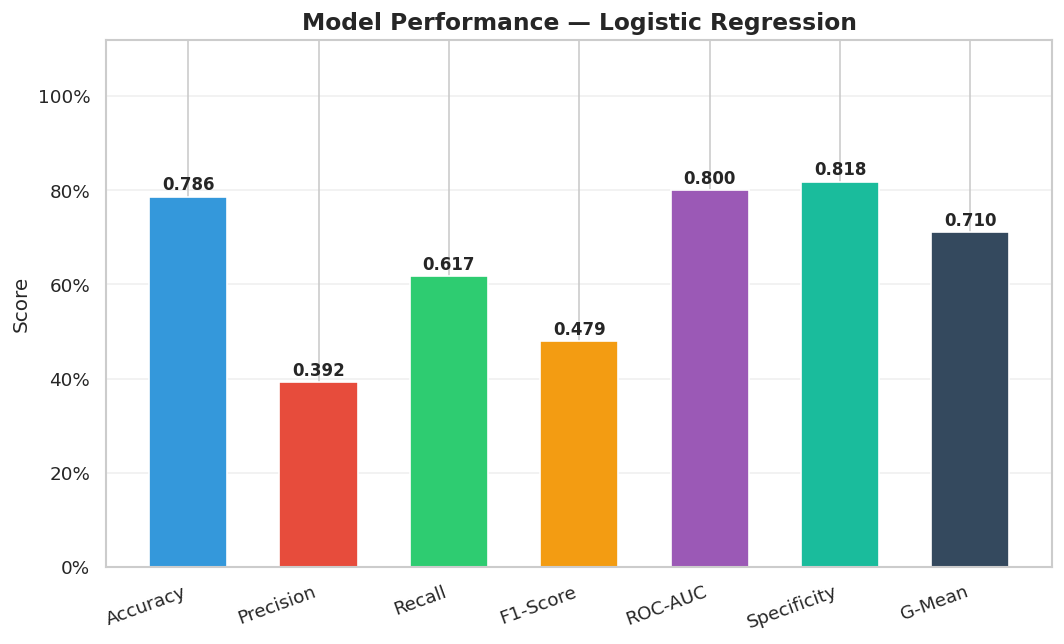

Saved: 08_perf_Logistic_Regression.png



In [27]:
metrics_list  = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Specificity','G-Mean']
metric_colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#34495e']

def plot_model_performance(model_name, results_df, metrics, colors, save_prefix):
    row    = results_df[results_df['Model'] == model_name].iloc[0]
    values = [row[m] for m in metrics]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    bars = ax.bar(metrics, values, color=colors, edgecolor='white', width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.015,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
    ax.set_title(f'Model Performance — {model_name}', fontsize=14, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.grid(axis='y', alpha=0.3); plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    safe = model_name.replace(' ','_').replace('+','plus')
    plt.savefig(f'{save_prefix}_{safe}.png', bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_prefix}_{safe}.png\n")

plot_model_performance('Logistic Regression', results, metrics_list, metric_colors, '08_perf')

**Performance Chart: Decision Tree**

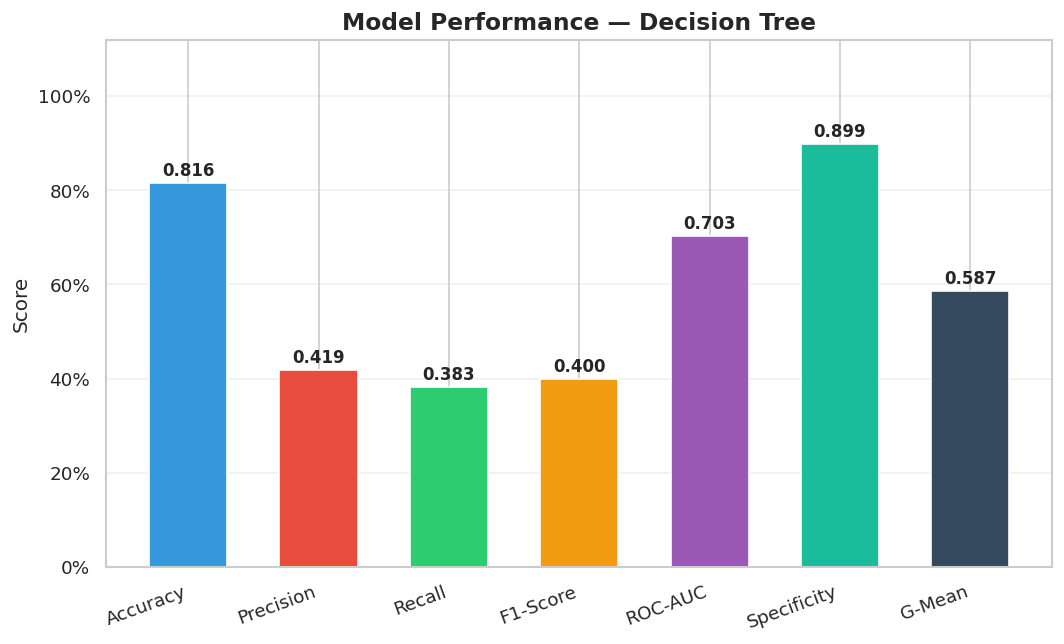

Saved: 08_perf_Decision_Tree.png



In [28]:
plot_model_performance('Decision Tree', results, metrics_list, metric_colors, '08_perf')

**Performance Chart: Random Forest**

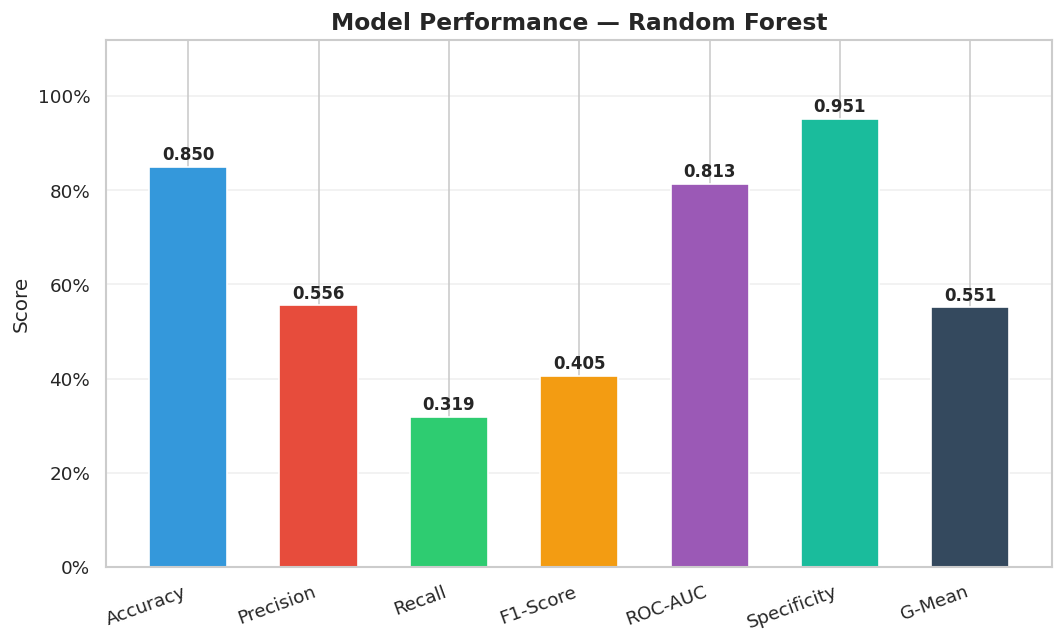

Saved: 08_perf_Random_Forest.png



In [29]:
plot_model_performance('Random Forest', results, metrics_list, metric_colors, '08_perf')

**Performance Chart: XGBoost**

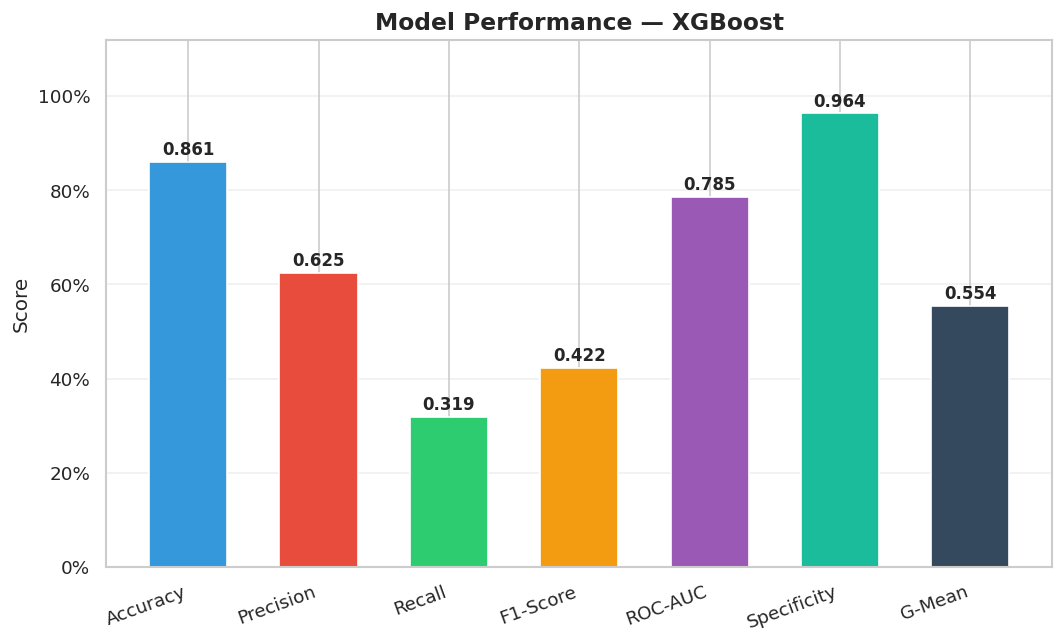

Saved: 08_perf_XGBoost.png



In [30]:
plot_model_performance('XGBoost', results, metrics_list, metric_colors, '08_perf')

**Performance Chart: SVM**

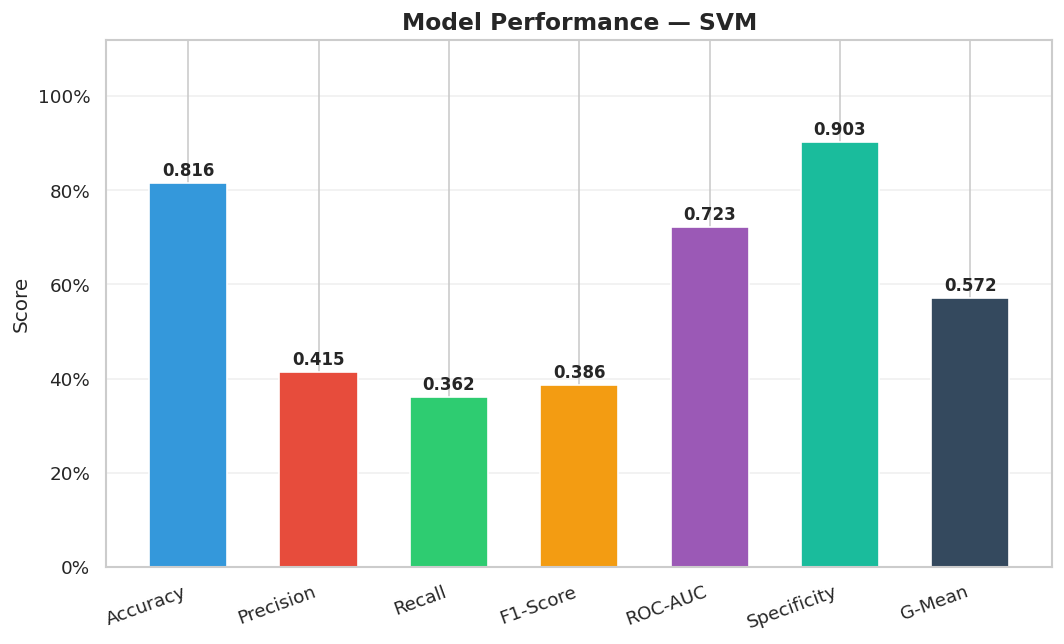

Saved: 08_perf_SVM.png



In [31]:
plot_model_performance('SVM', results, metrics_list, metric_colors, '08_perf')

**Performance Chart: Neural Network**

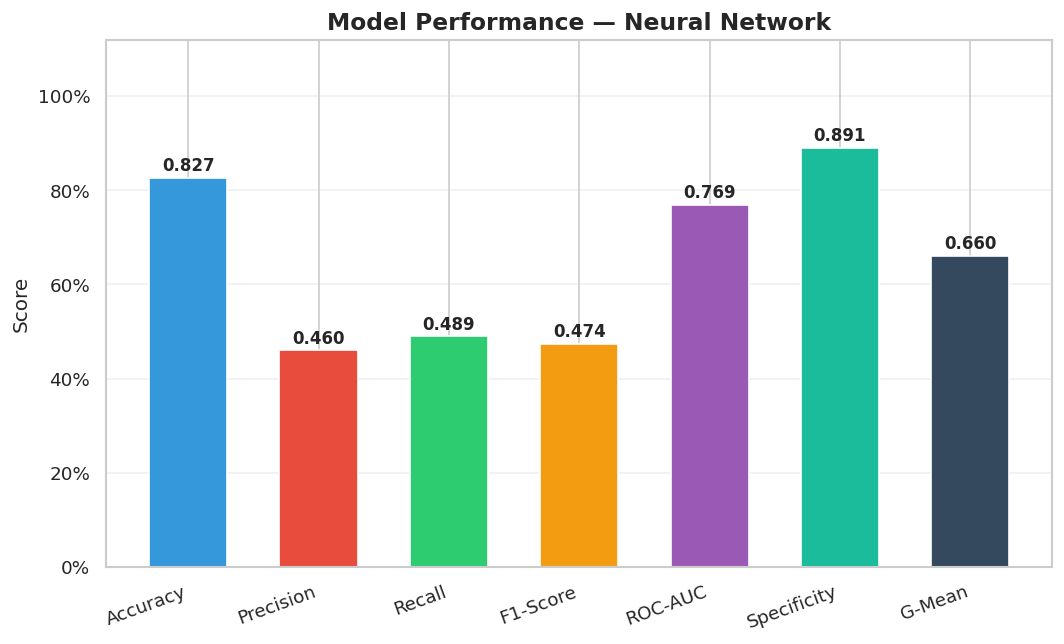

Saved: 08_perf_Neural_Network.png



In [32]:
plot_model_performance('Neural Network', results, metrics_list, metric_colors, '08_perf')

**Performance Chart: RF + Neural Network (Hybrid 1)**

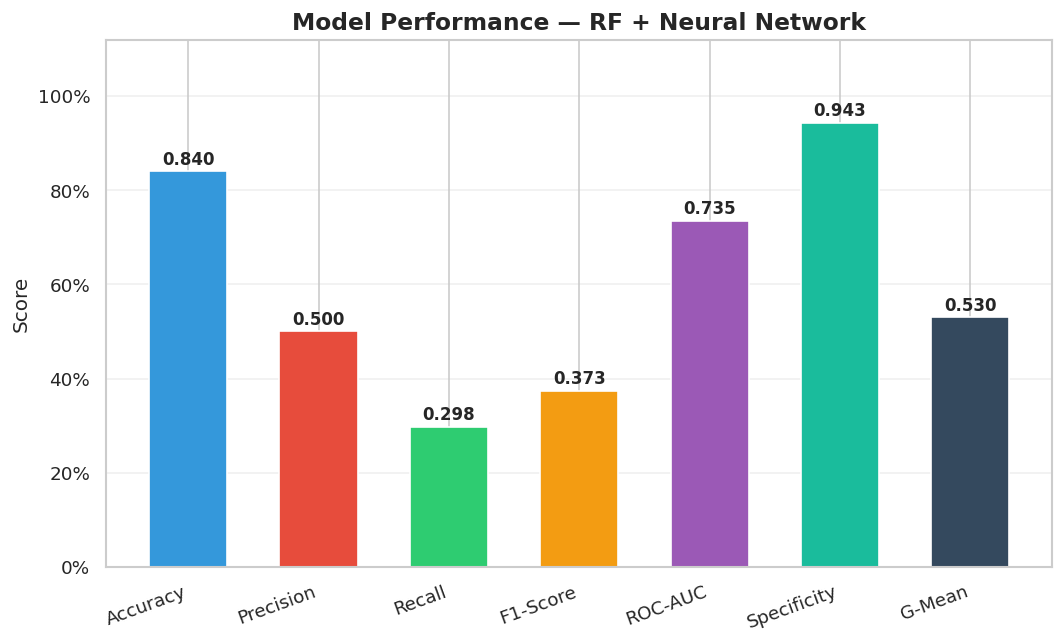

Saved: 08_perf_RF_plus_Neural_Network.png



In [33]:
plot_model_performance('RF + Neural Network', results, metrics_list, metric_colors, '08_perf')

**Performance Chart: GB + Deep Learning (Hybrid 2)**

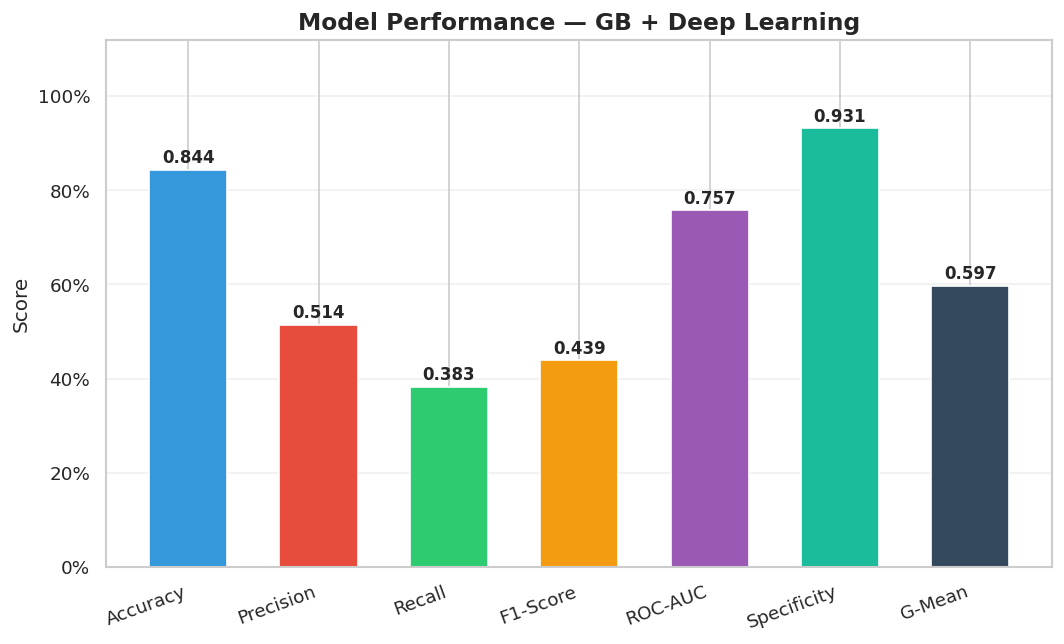

Saved: 08_perf_GB_plus_Deep_Learning.png



In [34]:
plot_model_performance('GB + Deep Learning', results, metrics_list, metric_colors, '08_perf')

**Plot: Confusion Matrices (All 6 Models)**

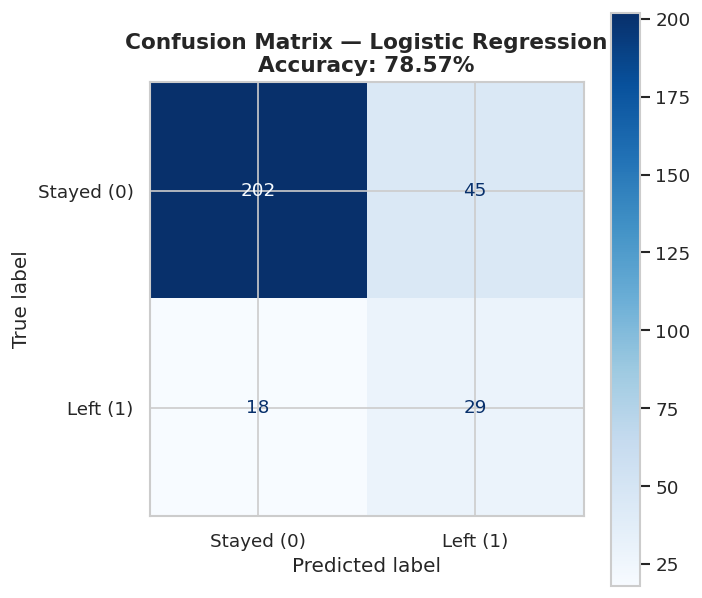

   TN=202  FP=45  FN=18  TP=29
   → Correctly caught 29 leavers | Missed 18 | 45 false alarms

Saved: 09_cm_Logistic_Regression.png



In [35]:
def plot_confusion_matrix(model_name, preds_dict, y_true, save_prefix):
    yp  = preds_dict[model_name]
    cm  = confusion_matrix(y_true, yp)
    acc = accuracy_score(y_true, yp)
    fig, ax = plt.subplots(figsize=(6, 5.5))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed (0)', 'Left (1)'])
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
    ax.set_title(f'Confusion Matrix — {model_name}\nAccuracy: {acc:.2%}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    safe = model_name.replace(' ','_').replace('+','plus')
    plt.savefig(f'{save_prefix}_{safe}.png', bbox_inches='tight')
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"   TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"   → Correctly caught {tp} leavers | Missed {fn} | {fp} false alarms\n")
    print(f"Saved: {save_prefix}_{safe}.png\n")

plot_confusion_matrix('Logistic Regression', preds, y_test, '09_cm')


**Confusion Matrix: Decision Tree**

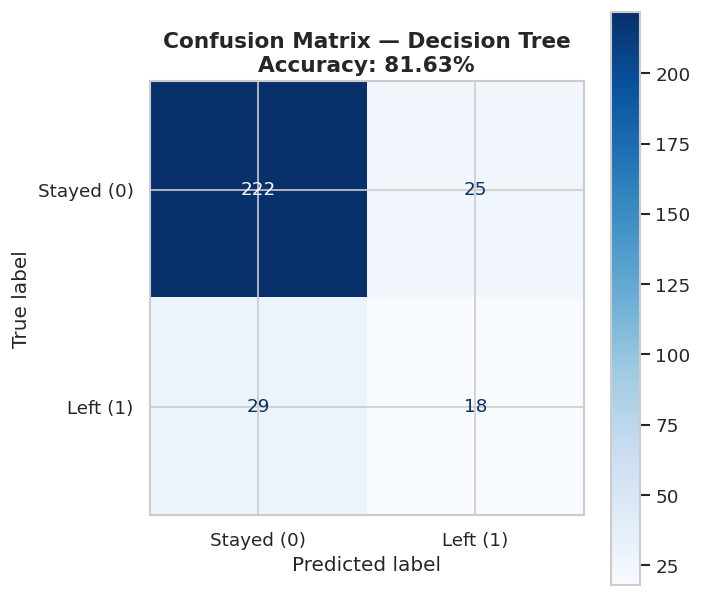

   TN=222  FP=25  FN=29  TP=18
   → Correctly caught 18 leavers | Missed 29 | 25 false alarms

Saved: 09_cm_Decision_Tree.png



In [36]:
plot_confusion_matrix('Decision Tree', preds, y_test, '09_cm')

**Confusion Matrix: Random Forest**

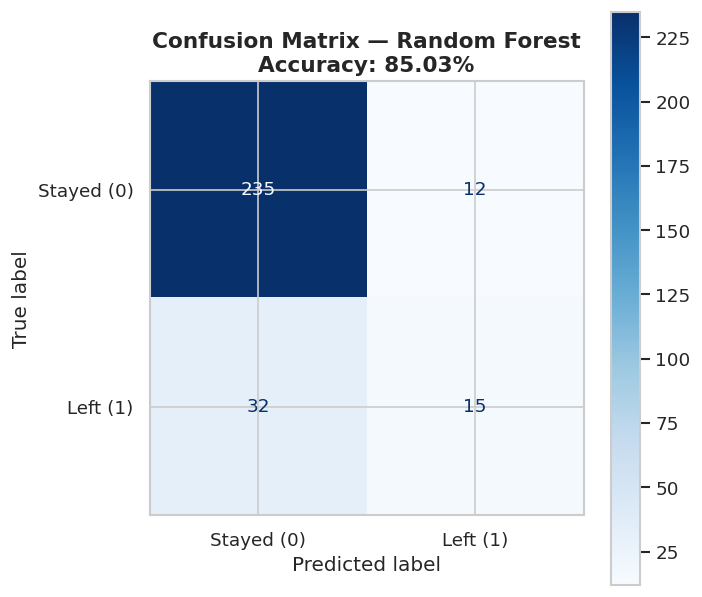

   TN=235  FP=12  FN=32  TP=15
   → Correctly caught 15 leavers | Missed 32 | 12 false alarms

Saved: 09_cm_Random_Forest.png



In [37]:
plot_confusion_matrix('Random Forest', preds, y_test, '09_cm')

**Confusion Matrix: XGBoost**

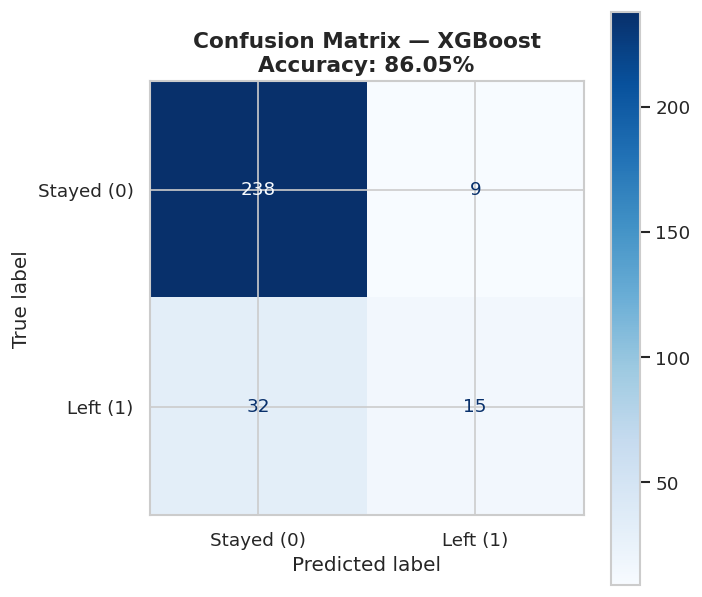

   TN=238  FP=9  FN=32  TP=15
   → Correctly caught 15 leavers | Missed 32 | 9 false alarms

Saved: 09_cm_XGBoost.png



In [38]:
plot_confusion_matrix('XGBoost', preds, y_test, '09_cm')

**Confusion Matrix: SVM**

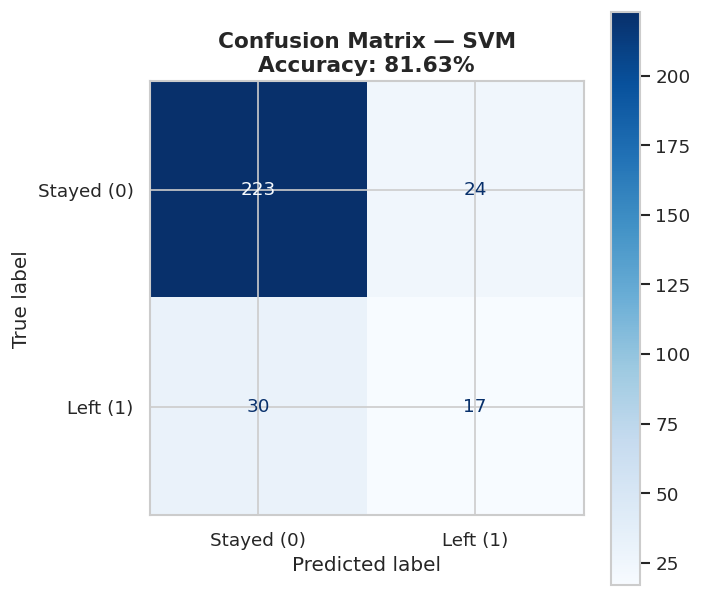

   TN=223  FP=24  FN=30  TP=17
   → Correctly caught 17 leavers | Missed 30 | 24 false alarms

Saved: 09_cm_SVM.png



In [39]:
plot_confusion_matrix('SVM', preds, y_test, '09_cm')

**Confusion Matrix: Neural Network**

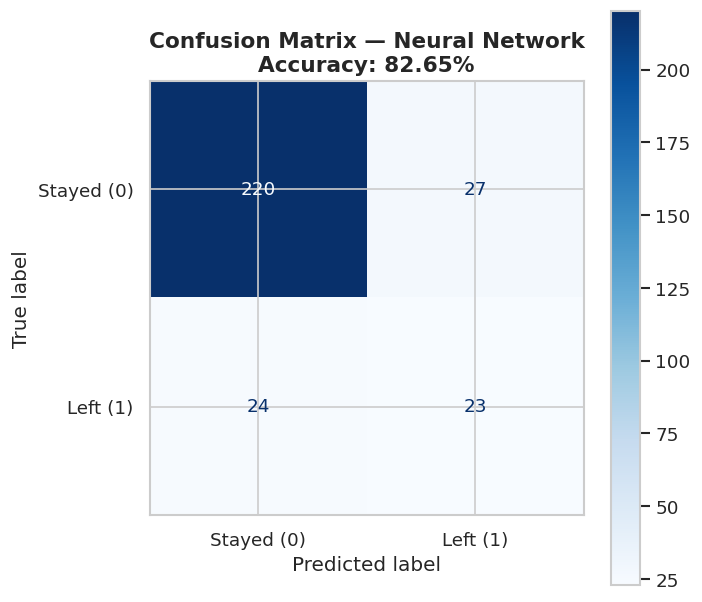

   TN=220  FP=27  FN=24  TP=23
   → Correctly caught 23 leavers | Missed 24 | 27 false alarms

Saved: 09_cm_Neural_Network.png



In [40]:
plot_confusion_matrix('Neural Network', preds, y_test, '09_cm')

**Confusion Matrix: RF + Neural Network (Hybrid 1)**

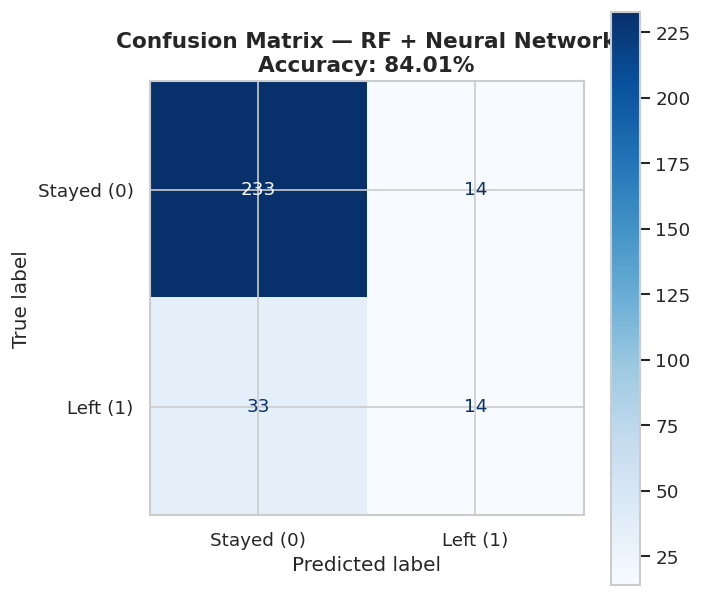

   TN=233  FP=14  FN=33  TP=14
   → Correctly caught 14 leavers | Missed 33 | 14 false alarms

Saved: 09_cm_RF_plus_Neural_Network.png



In [41]:
plot_confusion_matrix('RF + Neural Network', preds, y_test, '09_cm')

**Confusion Matrix: GB + Deep Learning (Hybrid 2)**

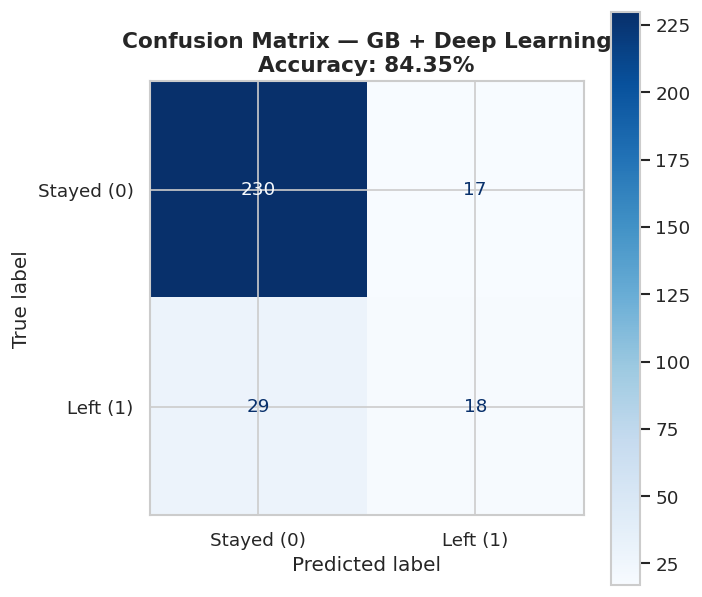

   TN=230  FP=17  FN=29  TP=18
   → Correctly caught 18 leavers | Missed 29 | 17 false alarms

Saved: 09_cm_GB_plus_Deep_Learning.png



In [42]:
plot_confusion_matrix('GB + Deep Learning', preds, y_test, '09_cm')

**Plot: ROC Curves**

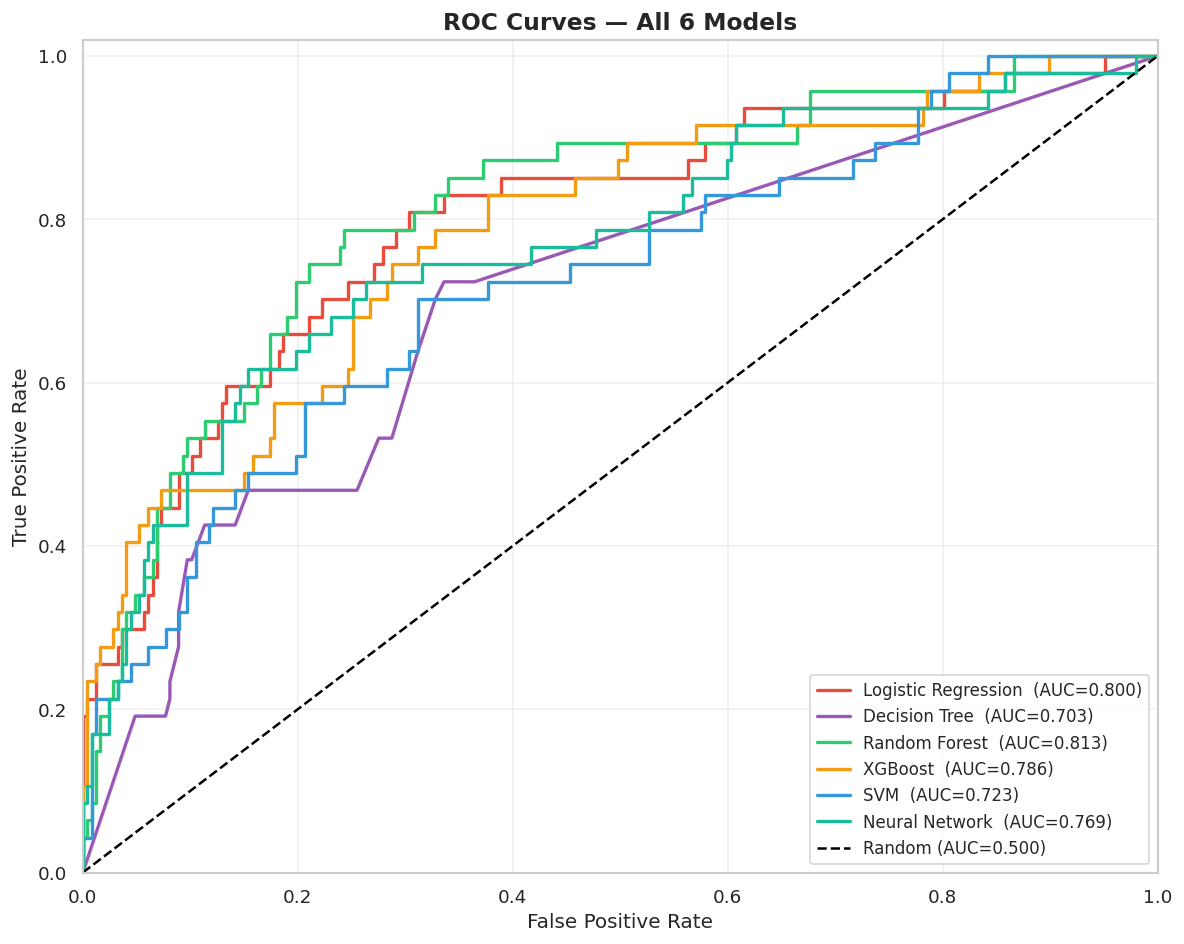

In [43]:
roc_colors = ['#e74c3c','#9b59b6','#2ecc71','#f39c12','#3498db','#1abc9c']

plt.figure(figsize=(10, 8))
for (name, ypr), color in zip(probs.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, ypr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name}  (AUC={auc(fpr, tpr):.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Random (AUC=0.500)')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All 6 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('10_roc_curves.png', bbox_inches='tight')
plt.show()

**Plot: Feature Importance (3 Tree-Based Models)**

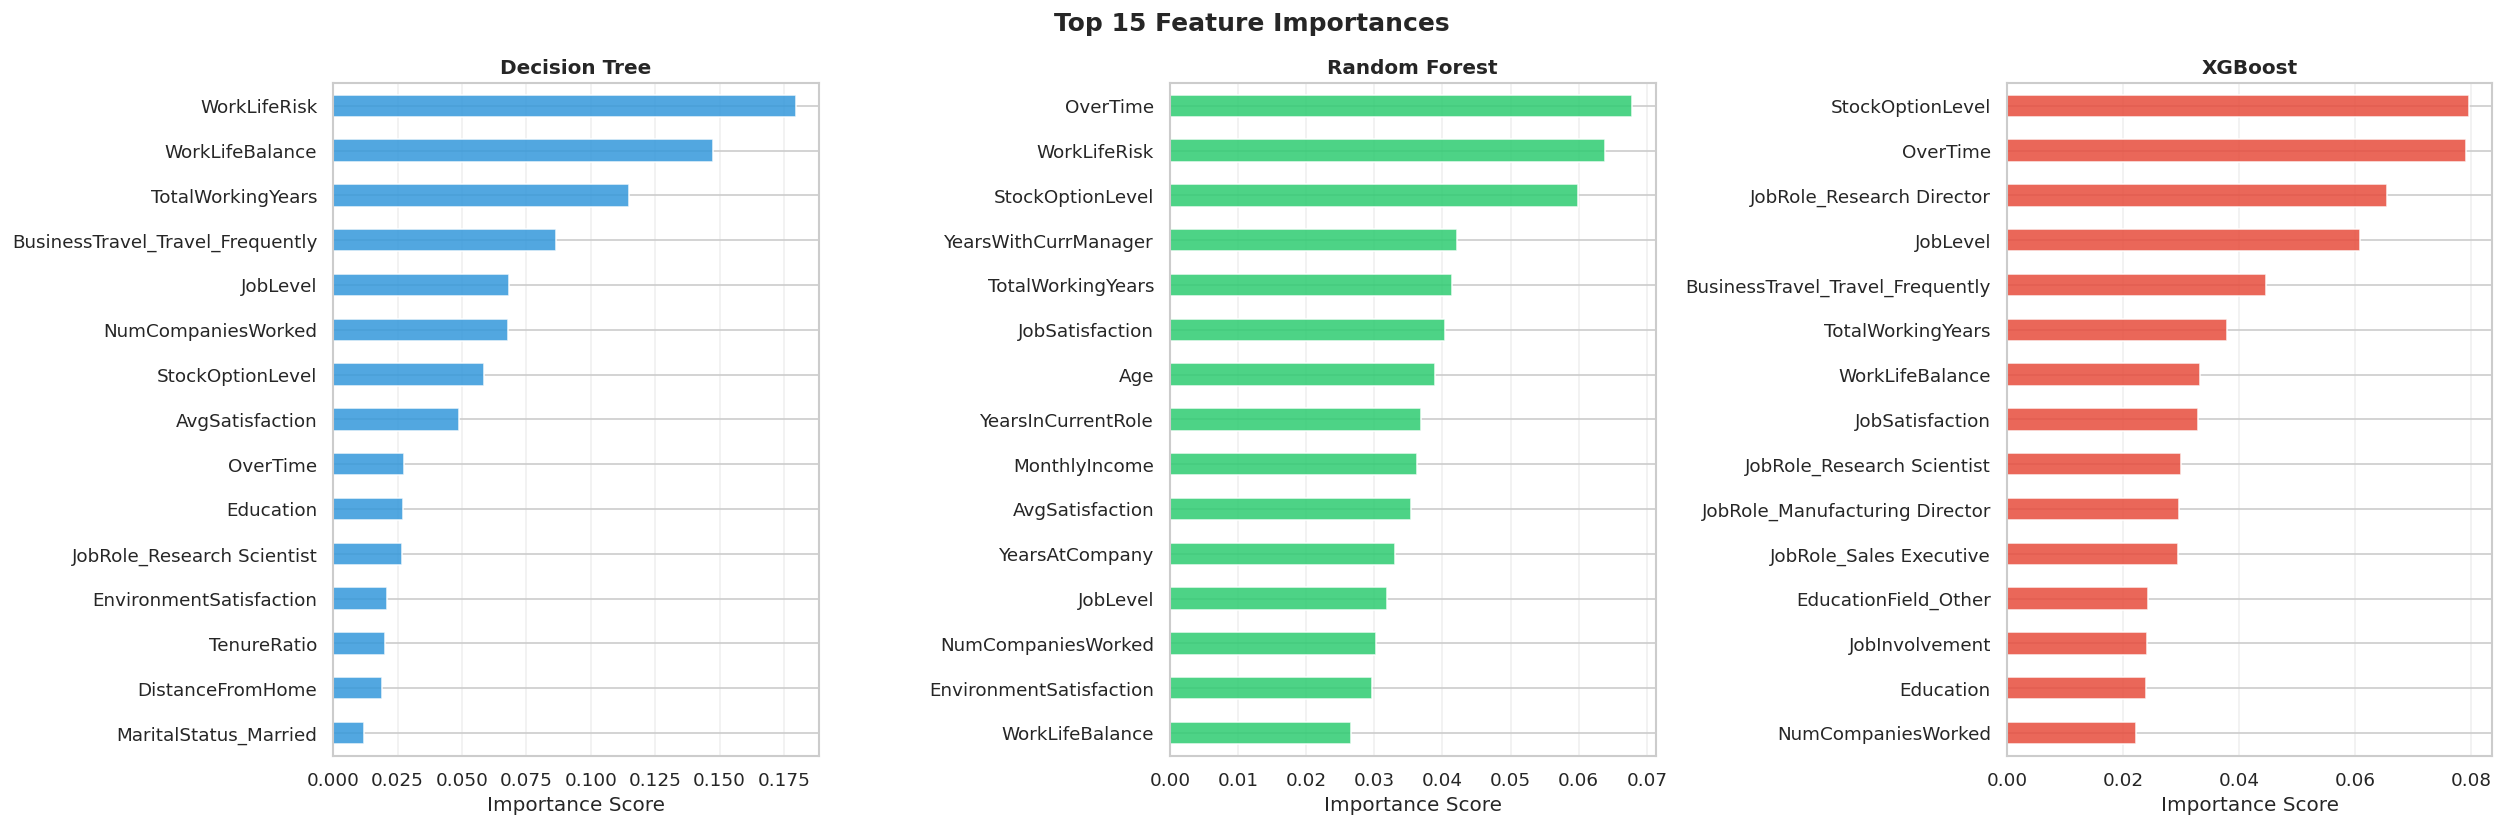

In [44]:
tree_models = {k: v for k, v in trained.items()
               if k in ['Decision Tree','Random Forest','XGBoost']}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Top 15 Feature Importances',
             fontsize=15, fontweight='bold')

feature_names = X_train.columns.tolist()
colors_fi = ['#3498db','#2ecc71','#e74c3c']

for ax, (name, model), color in zip(axes, tree_models.items(), colors_fi):
    imp   = pd.Series(model.feature_importances_, index=feature_names)
    top15 = imp.nlargest(15).sort_values()
    top15.plot(kind='barh', ax=ax, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('11_feature_importance.png', bbox_inches='tight')
plt.show()

**SHAP Analysis (XGBoost)**

SHAP ANALYSIS — XGBoost (Best Model)


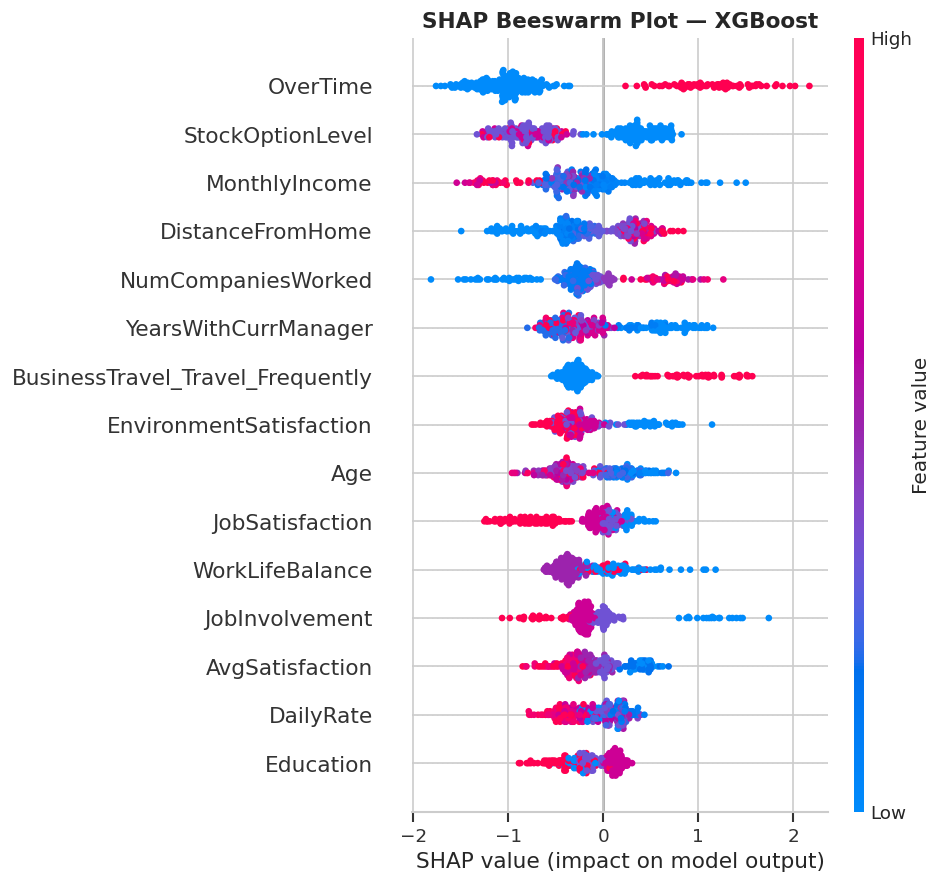

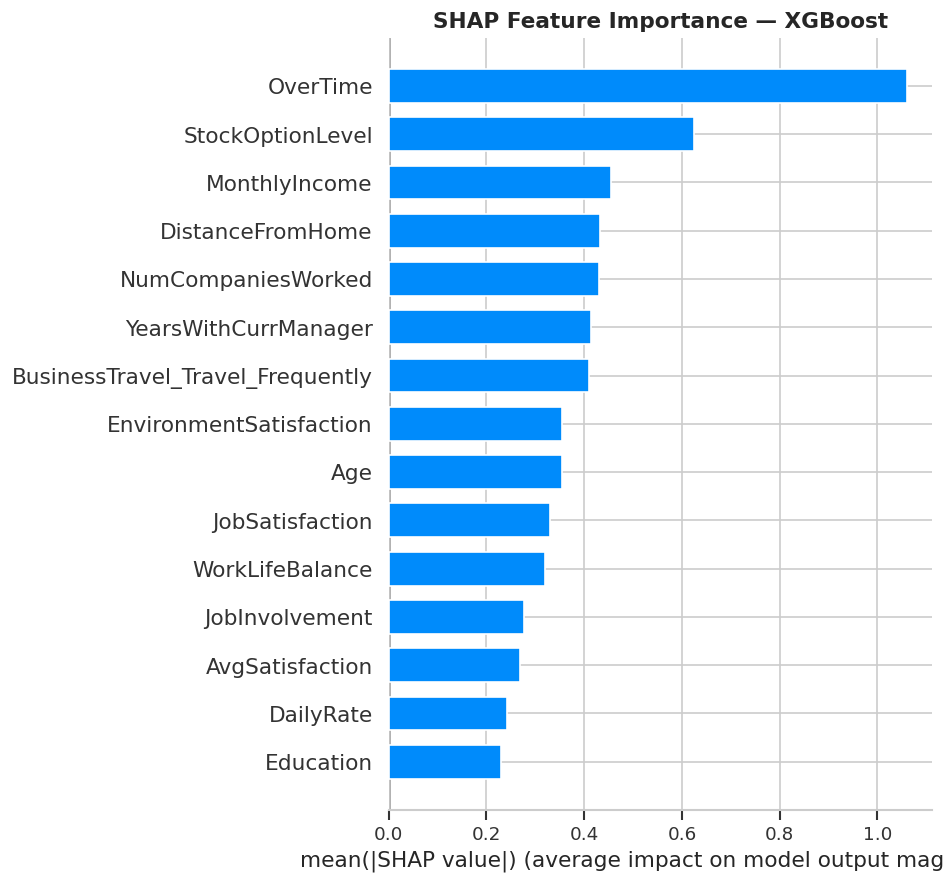

In [45]:
print("SHAP ANALYSIS — XGBoost (Best Model)")

explainer   = shap.TreeExplainer(trained['XGBoost'])
shap_values = explainer.shap_values(X_test_sc)

# Beeswarm summary plot
plt.figure()
shap.summary_plot(shap_values, X_test_sc,
                  plot_type='dot', max_display=15, show=False)
plt.title('SHAP Beeswarm Plot — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('12_shap_beeswarm.png', bbox_inches='tight')
plt.show()

# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_test_sc,
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('13_shap_bar.png', bbox_inches='tight')
plt.show()

**Cross-Validation**

5-FOLD CROSS-VALIDATION (F1-Score)
  Logistic Regression     mean=0.4904  std=±0.0188
  Decision Tree           mean=0.4039  std=±0.0197
  Random Forest           mean=0.4061  std=±0.1068
  XGBoost                 mean=0.4373  std=±0.0888
  SVM                     mean=0.5297  std=±0.0719
  Neural Network          mean=0.4397  std=±0.0399
  RF + Neural Network     mean=0.4397  std=±0.0399
  GB + Deep Learning      mean=0.3561  std=±0.1653


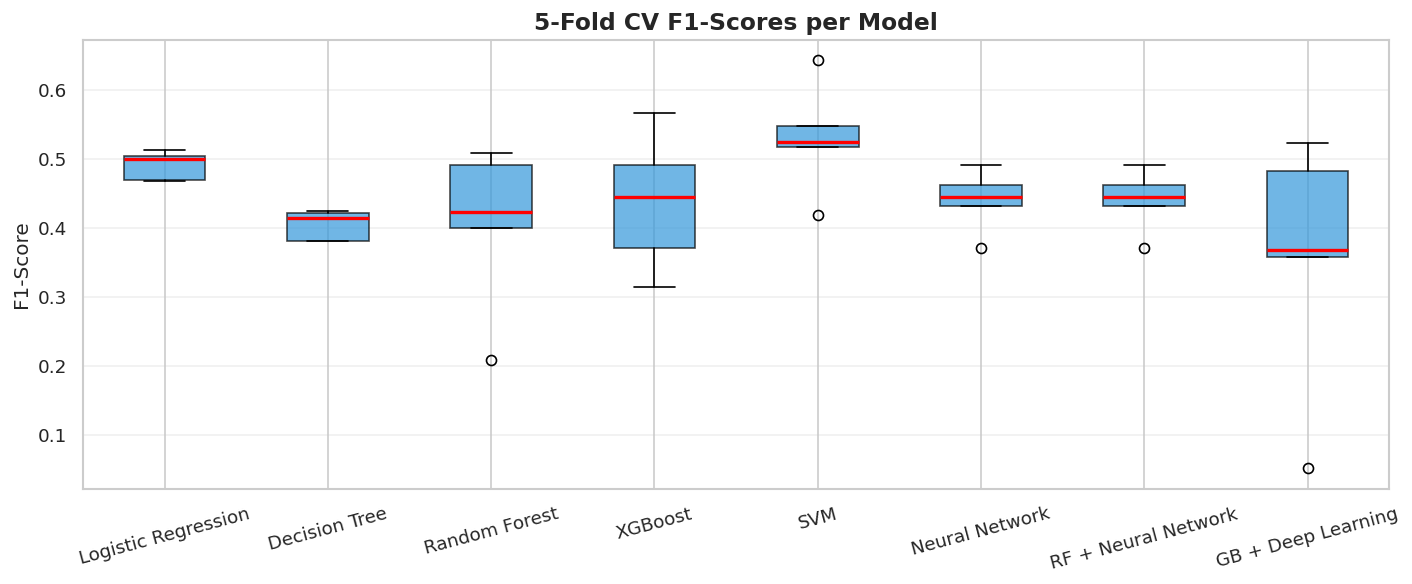

In [46]:
print("5-FOLD CROSS-VALIDATION (F1-Score)")

cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in trained.items():
    scores = cross_val_score(model, X_train_sc, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<22}  mean={scores.mean():.4f}  std=±{scores.std():.4f}")

# Boxplot
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(cv_results.values(),
           labels=cv_results.keys(),
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold CV F1-Scores per Model',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('14_cross_validation.png', bbox_inches='tight')
plt.show()

**Final Summary**

In [47]:
best = results.iloc[0]

print("FINAL PROJECT SUMMARY")
print(f"\n Best Model     : {best['Model']}")
print(f"   Accuracy       : {best['Accuracy']*100:.2f}%")
print(f"   Precision      : {best['Precision']*100:.2f}%")
print(f"   Recall         : {best['Recall']*100:.2f}%")
print(f"   F1-Score       : {best['F1-Score']*100:.2f}%")
print(f"   ROC-AUC        : {best['ROC-AUC']*100:.2f}%")
print(f"   G-Mean         : {best['G-Mean']*100:.2f}%")

print("\n Files generated:")
for f in [
    "01_attrition_distribution.png",
    "02_numerical_features.png",
    "03_categorical_features.png",
    "04_satisfaction_scores.png",
    "05_compensation_performance.png",
    "06_correlation_heatmap.png",
    "07_smote.png",
    "08_model_comparison.png",
    "09_confusion_matrices.png",
    "10_roc_curves.png",
    "11_feature_importance.png",
    "12_shap_beeswarm.png",
    "13_shap_bar.png",
    "14_cross_validation.png",
    "model_results.csv",
]:
    print(f"    {f}")


FINAL PROJECT SUMMARY

 Best Model     : Logistic Regression
   Accuracy       : 78.57%
   Precision      : 39.19%
   Recall         : 61.70%
   F1-Score       : 47.93%
   ROC-AUC        : 79.99%
   G-Mean         : 71.04%

 Files generated:
    01_attrition_distribution.png
    02_numerical_features.png
    03_categorical_features.png
    04_satisfaction_scores.png
    05_compensation_performance.png
    06_correlation_heatmap.png
    07_smote.png
    08_model_comparison.png
    09_confusion_matrices.png
    10_roc_curves.png
    11_feature_importance.png
    12_shap_beeswarm.png
    13_shap_bar.png
    14_cross_validation.png
    model_results.csv


In [48]:
print(f'Total Features: {len(X.columns)}\n')
print('Feature Composition List:')
for i, col in enumerate(X.columns, 1):
    print(f'{i:2d}. {col}')

Total Features: 49

Feature Composition List:
 1. Age
 2. DailyRate
 3. DistanceFromHome
 4. Education
 5. EnvironmentSatisfaction
 6. Gender
 7. HourlyRate
 8. JobInvolvement
 9. JobLevel
10. JobSatisfaction
11. MonthlyIncome
12. MonthlyRate
13. NumCompaniesWorked
14. OverTime
15. PercentSalaryHike
16. PerformanceRating
17. RelationshipSatisfaction
18. StockOptionLevel
19. TotalWorkingYears
20. TrainingTimesLastYear
21. WorkLifeBalance
22. YearsAtCompany
23. YearsInCurrentRole
24. YearsSinceLastPromotion
25. YearsWithCurrManager
26. Department_Research & Development
27. Department_Sales
28. EducationField_Life Sciences
29. EducationField_Marketing
30. EducationField_Medical
31. EducationField_Other
32. EducationField_Technical Degree
33. JobRole_Human Resources
34. JobRole_Laboratory Technician
35. JobRole_Manager
36. JobRole_Manufacturing Director
37. JobRole_Research Director
38. JobRole_Research Scientist
39. JobRole_Sales Executive
40. JobRole_Sales Representative
41. MaritalStatu